# EDA — Sistema de Entregas de Comida
> **Análisis Exploratorio de Datos** | Cuatro ejes estratégicos: Operaciones · Clientes · Promociones · Riesgo Operativo

Dataset procesado: `food_delivery_processed.csv`  
Registros: **15,000** órdenes · **40** variables

---
| Sección | Tema | Variables clave |
|---------|------|-----------------|
| §01 Descripción general | Visión general del dataset | Todas |
| §02 Distribuciones univariadas | Comportamiento de cada métrica | Numéricas continuas |
| §03 Patrones temporales | Cuándo se ordena y cómo afecta al tiempo | `order_hour`, `order_day_of_week`, `order_month` |
| §04 Física de la entrega | Distancia, tiempo, clima y experiencia del repartidor | `delivery_distance_km`, `delivery_time_minutes`, `weather_severity_score` |
| §05 Economía del pedido | Revenue, descuentos, propinas y segmentos | `order_value`, `final_amount_paid`, `discount_amount`, `tip_amount` |
| §06 Clientes y satisfacción | Segmentación por lealtad, edad y tipo de cliente | `customer_loyalty_score`, `customer_rating`, `premium_customer_flag` |
| §07 Riesgo operativo | Cancelaciones, retrasos y reembolsos | `cancellation_flag`, `delayed_delivery_flag`, `refund_flag` |
| §08 Desempeño del repartidor | Experiencia vs eficiencia vs calificación | `delivery_partner_experience_years`, `delivery_efficiency_score` |
| §09 Matriz de correlación | Relaciones entre todas las variables | Todas numéricas |
| §10 Conclusiones | Hallazgos e insights accionables | — |

---
## Configuración y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, mannwhitneyu, f_oneway, spearmanr, pearsonr, ttest_ind
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'jinja2'], check=False)
import warnings
warnings.filterwarnings('ignore')

# ── Paleta y estilo (configuracion de eda_food_delivery.ipynb)
PALETTE = {
    'low':      '#5d9fd4',
    'medium':   '#4aaa77',
    'high':     '#e06b4e',
    'veryhigh': '#a87dd4',
    'premium':  '#5d9fd4',
    'standard': '#e06b4e',
    'discount': '#4aaa77',
    'no_disc':  '#a87dd4',
    'margin':   '#e06b4e',
}

# Lista de colores para graficos multi-serie
COLORS = ['#5d9fd4', '#4aaa77', '#e06b4e', '#a87dd4', '#f59e0b', '#8b5cf6', '#ef4444', '#14b8a6']
BG = '#FAFAF8'

plt.rcParams.update({
    'figure.facecolor':   BG,
    'axes.facecolor':     BG,
    'axes.grid':          True,
    'grid.color':         '#E5E3DF',
    'grid.linewidth':     0.6,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'figure.dpi':         140,
})

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


In [2]:
df = pd.read_csv('../data/processed/food_delivery_processed.csv')

# Feature engineering derivado
df['delivery_delay_minutes'] = df['delivery_time_minutes'] - df['estimated_delivery_time']
df['revenue_per_km']         = df['final_amount_paid'] / df['delivery_distance_km'].replace(0, np.nan)
df['tip_rate']               = df['tip_amount'] / df['order_value']
df['discount_rate']          = df['discount_amount'] / df['order_value']
df['age_group']              = pd.cut(df['customer_age'], bins=[17,25,35,45,55,65],
                                      labels=['18-25','26-35','36-45','46-55','56-65'])
df['weather_bucket']         = pd.cut(df['weather_severity_score'], bins=5,
                                      labels=['Leve','Ligero','Moderado','Fuerte','Severo'])
df['loyalty_tier']           = pd.cut(df['customer_loyalty_score'], bins=5,
                                      labels=['Bronce','Plata','Oro','Platino','Diamante'])
df['exp_bucket']             = pd.cut(df['delivery_partner_experience_years'], bins=[0,3,6,10,15],
                                      labels=['1-3 años','4-6 años','7-10 años','11-15 años'])

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 15,000 filas x 48 columnas


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,peak_hour_flag,operational_risk_score,delivery_delay_minutes,revenue_per_km,tip_rate,discount_rate,age_group,weather_bucket,loyalty_tier,exp_bucket
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2.0,21.0,4.957522,20.0,6.0,6.0,14.117144,23.0,76.0,...,0,3.20,8.0,7.902716,0.199405,0.229694,18-25,Ligero,Bronce,7-10 años
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1.0,63.0,38.744720,0.0,2.0,2.0,9.177354,16.0,34.0,...,0,1.04,-6.0,12.646267,0.161019,0.044344,56-65,Leve,Plata,11-15 años
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1.0,68.0,45.170998,9.0,2.0,11.0,34.753920,41.0,152.0,...,0,4.96,10.0,3.214261,0.176815,0.149797,NaN,Moderado,Oro,7-10 años


---
# § 01 — Descripción general del dataset

In [3]:
# Mapa del esquema: tipos, nulos, unicos, muestra
info = pd.DataFrame({
    'tipo'    : df.dtypes.astype(str),
    'nulos'   : df.isnull().sum(),
    'nulos_%' : (df.isnull().mean() * 100).round(2),
    'unicos'  : df.nunique(),
    'muestra' : df.iloc[0],
})
info

,tipo,nulos,nulos_%,unicos,muestra
order_id,str,0,0.00,15000,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943
city_tier,float64,0,0.00,3,2.0
customer_age,float64,0,0.00,58,21.0
customer_loyalty_score,float64,0,0.00,14994,4.957522
order_hour,float64,0,0.00,24,20.0
order_day_of_week,float64,0,0.00,6,6.0
order_month,float64,0,0.00,12,6.0
delivery_distance_km,float64,0,0.00,14992,14.117144
preparation_time_minutes,float64,0,0.00,56,23.0
delivery_time_minutes,float64,0,0.00,171,76.0


In [5]:
df.describe(include='all').T.style.background_gradient(cmap='BuPu', subset=['mean','std','50%'])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,15000,15000,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,1,nan,nan,nan,nan,nan,nan,nan
city_tier,15000.000000,nan,nan,nan,2.253133,0.827951,1.000000,2.000000,3.000000,3.000000,3.000000
customer_age,15000.000000,nan,nan,nan,46.569667,16.840706,18.000000,32.000000,46.000000,61.000000,75.000000
customer_loyalty_score,15000.000000,nan,nan,nan,50.017658,28.771665,0.007172,25.199828,50.092270,74.840433,99.989370
order_hour,15000.000000,nan,nan,nan,11.470933,6.946134,0.000000,5.000000,11.000000,18.000000,23.000000
order_day_of_week,15000.000000,nan,nan,nan,3.141933,1.809864,1.000000,1.000000,3.000000,5.000000,6.000000
order_month,15000.000000,nan,nan,nan,6.474667,3.454469,1.000000,3.000000,7.000000,9.000000,12.000000
delivery_distance_km,15000.000000,nan,nan,nan,20.133756,11.543488,0.103086,10.133190,20.228710,30.047891,39.998737
preparation_time_minutes,15000.000000,nan,nan,nan,32.749667,16.162719,5.000000,19.000000,33.000000,47.000000,60.000000
delivery_time_minutes,15000.000000,nan,nan,nan,94.139267,33.597132,10.000000,68.000000,95.000000,120.000000,180.000000


---
# § 02 — Distribuciones univariadas

Vista individual de cada métrica numérica: forma de la distribución, media y mediana.

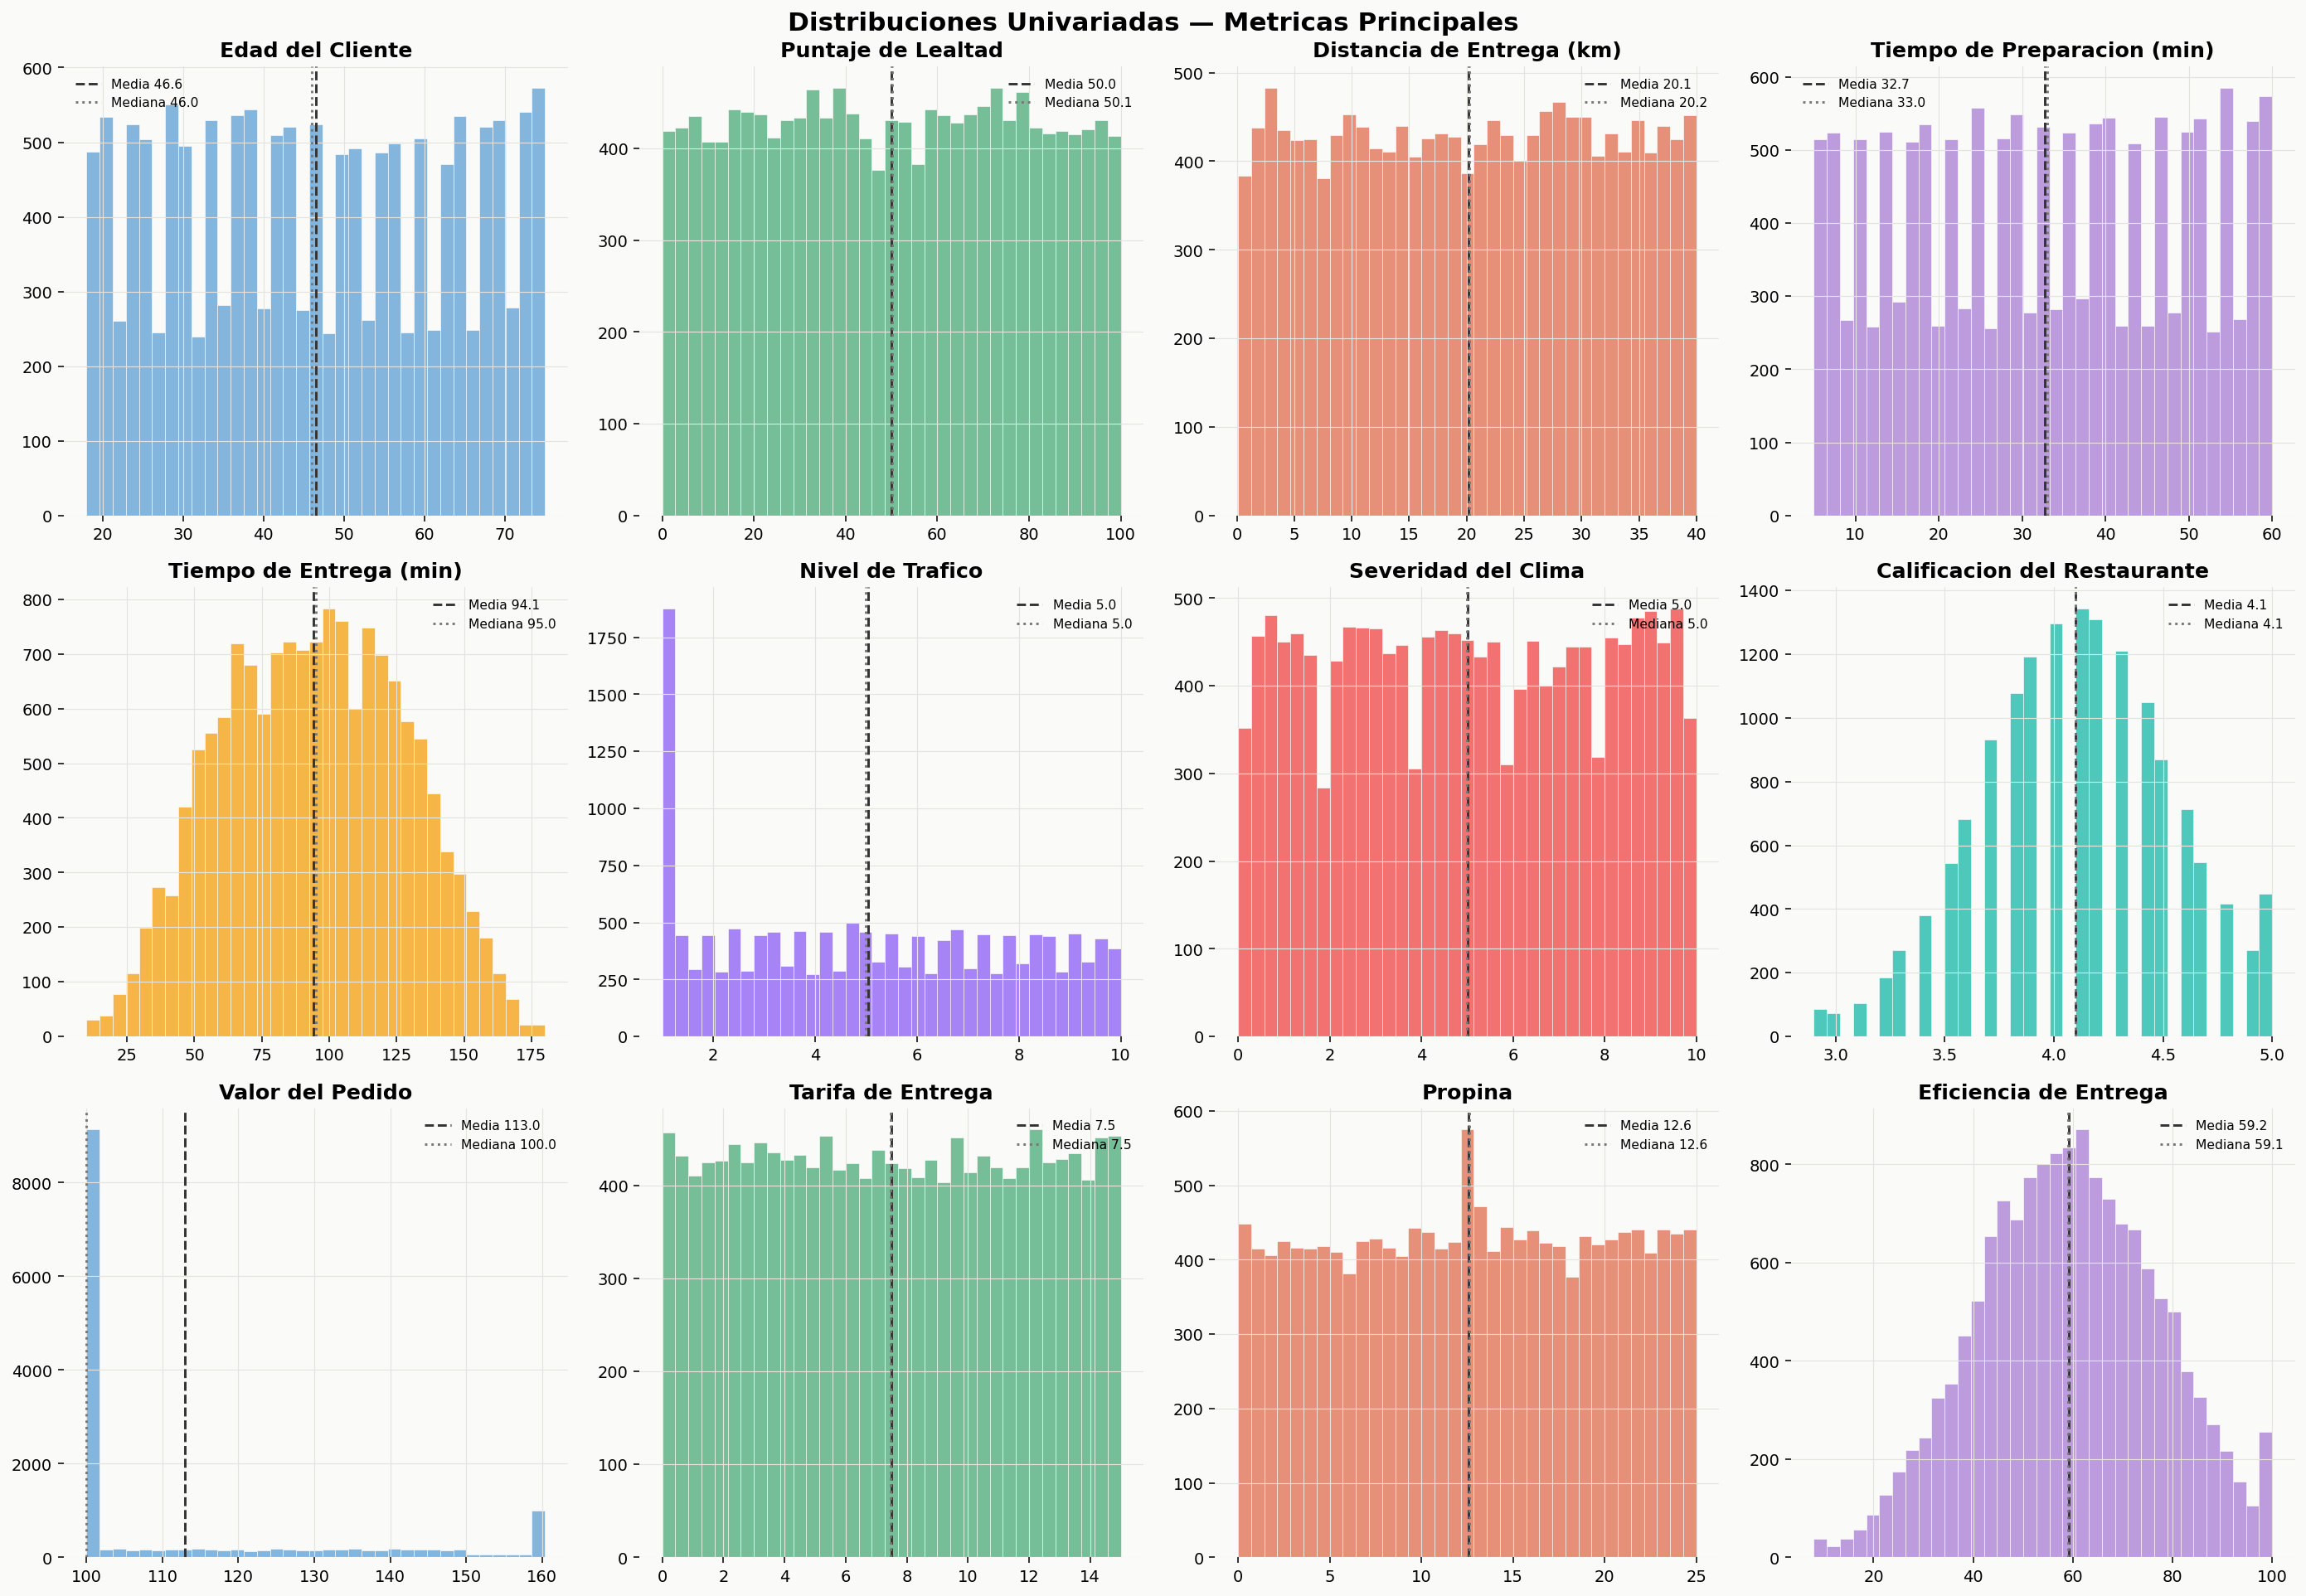

In [6]:
num_cols = [
    'customer_age', 'customer_loyalty_score', 'delivery_distance_km',
    'preparation_time_minutes', 'delivery_time_minutes', 'traffic_level_score',
    'weather_severity_score', 'restaurant_rating', 'order_value',
    'delivery_fee', 'tip_amount', 'delivery_efficiency_score'
]

labels_es = [
    'Edad del Cliente', 'Puntaje de Lealtad', 'Distancia de Entrega (km)',
    'Tiempo de Preparacion (min)', 'Tiempo de Entrega (min)', 'Nivel de Trafico',
    'Severidad del Clima', 'Calificacion del Restaurante', 'Valor del Pedido',
    'Tarifa de Entrega', 'Propina', 'Eficiencia de Entrega'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Distribuciones Univariadas — Metricas Principales', fontsize=16, fontweight='bold', y=0.98)

for ax, col, label, color in zip(axes.flat, num_cols, labels_es, COLORS * 2):
    data = df[col].dropna()
    ax.hist(data, bins=35, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color='#333', linestyle='--', linewidth=1.5, label=f'Media {data.mean():.1f}')
    ax.axvline(data.median(), color='#777', linestyle=':',  linewidth=1.5, label=f'Mediana {data.median():.1f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

---
# § 03 — Patrones temporales

El tiempo como arquitecto silencioso: cuándo ordena la gente y cómo afecta el rendimiento de las entregas.

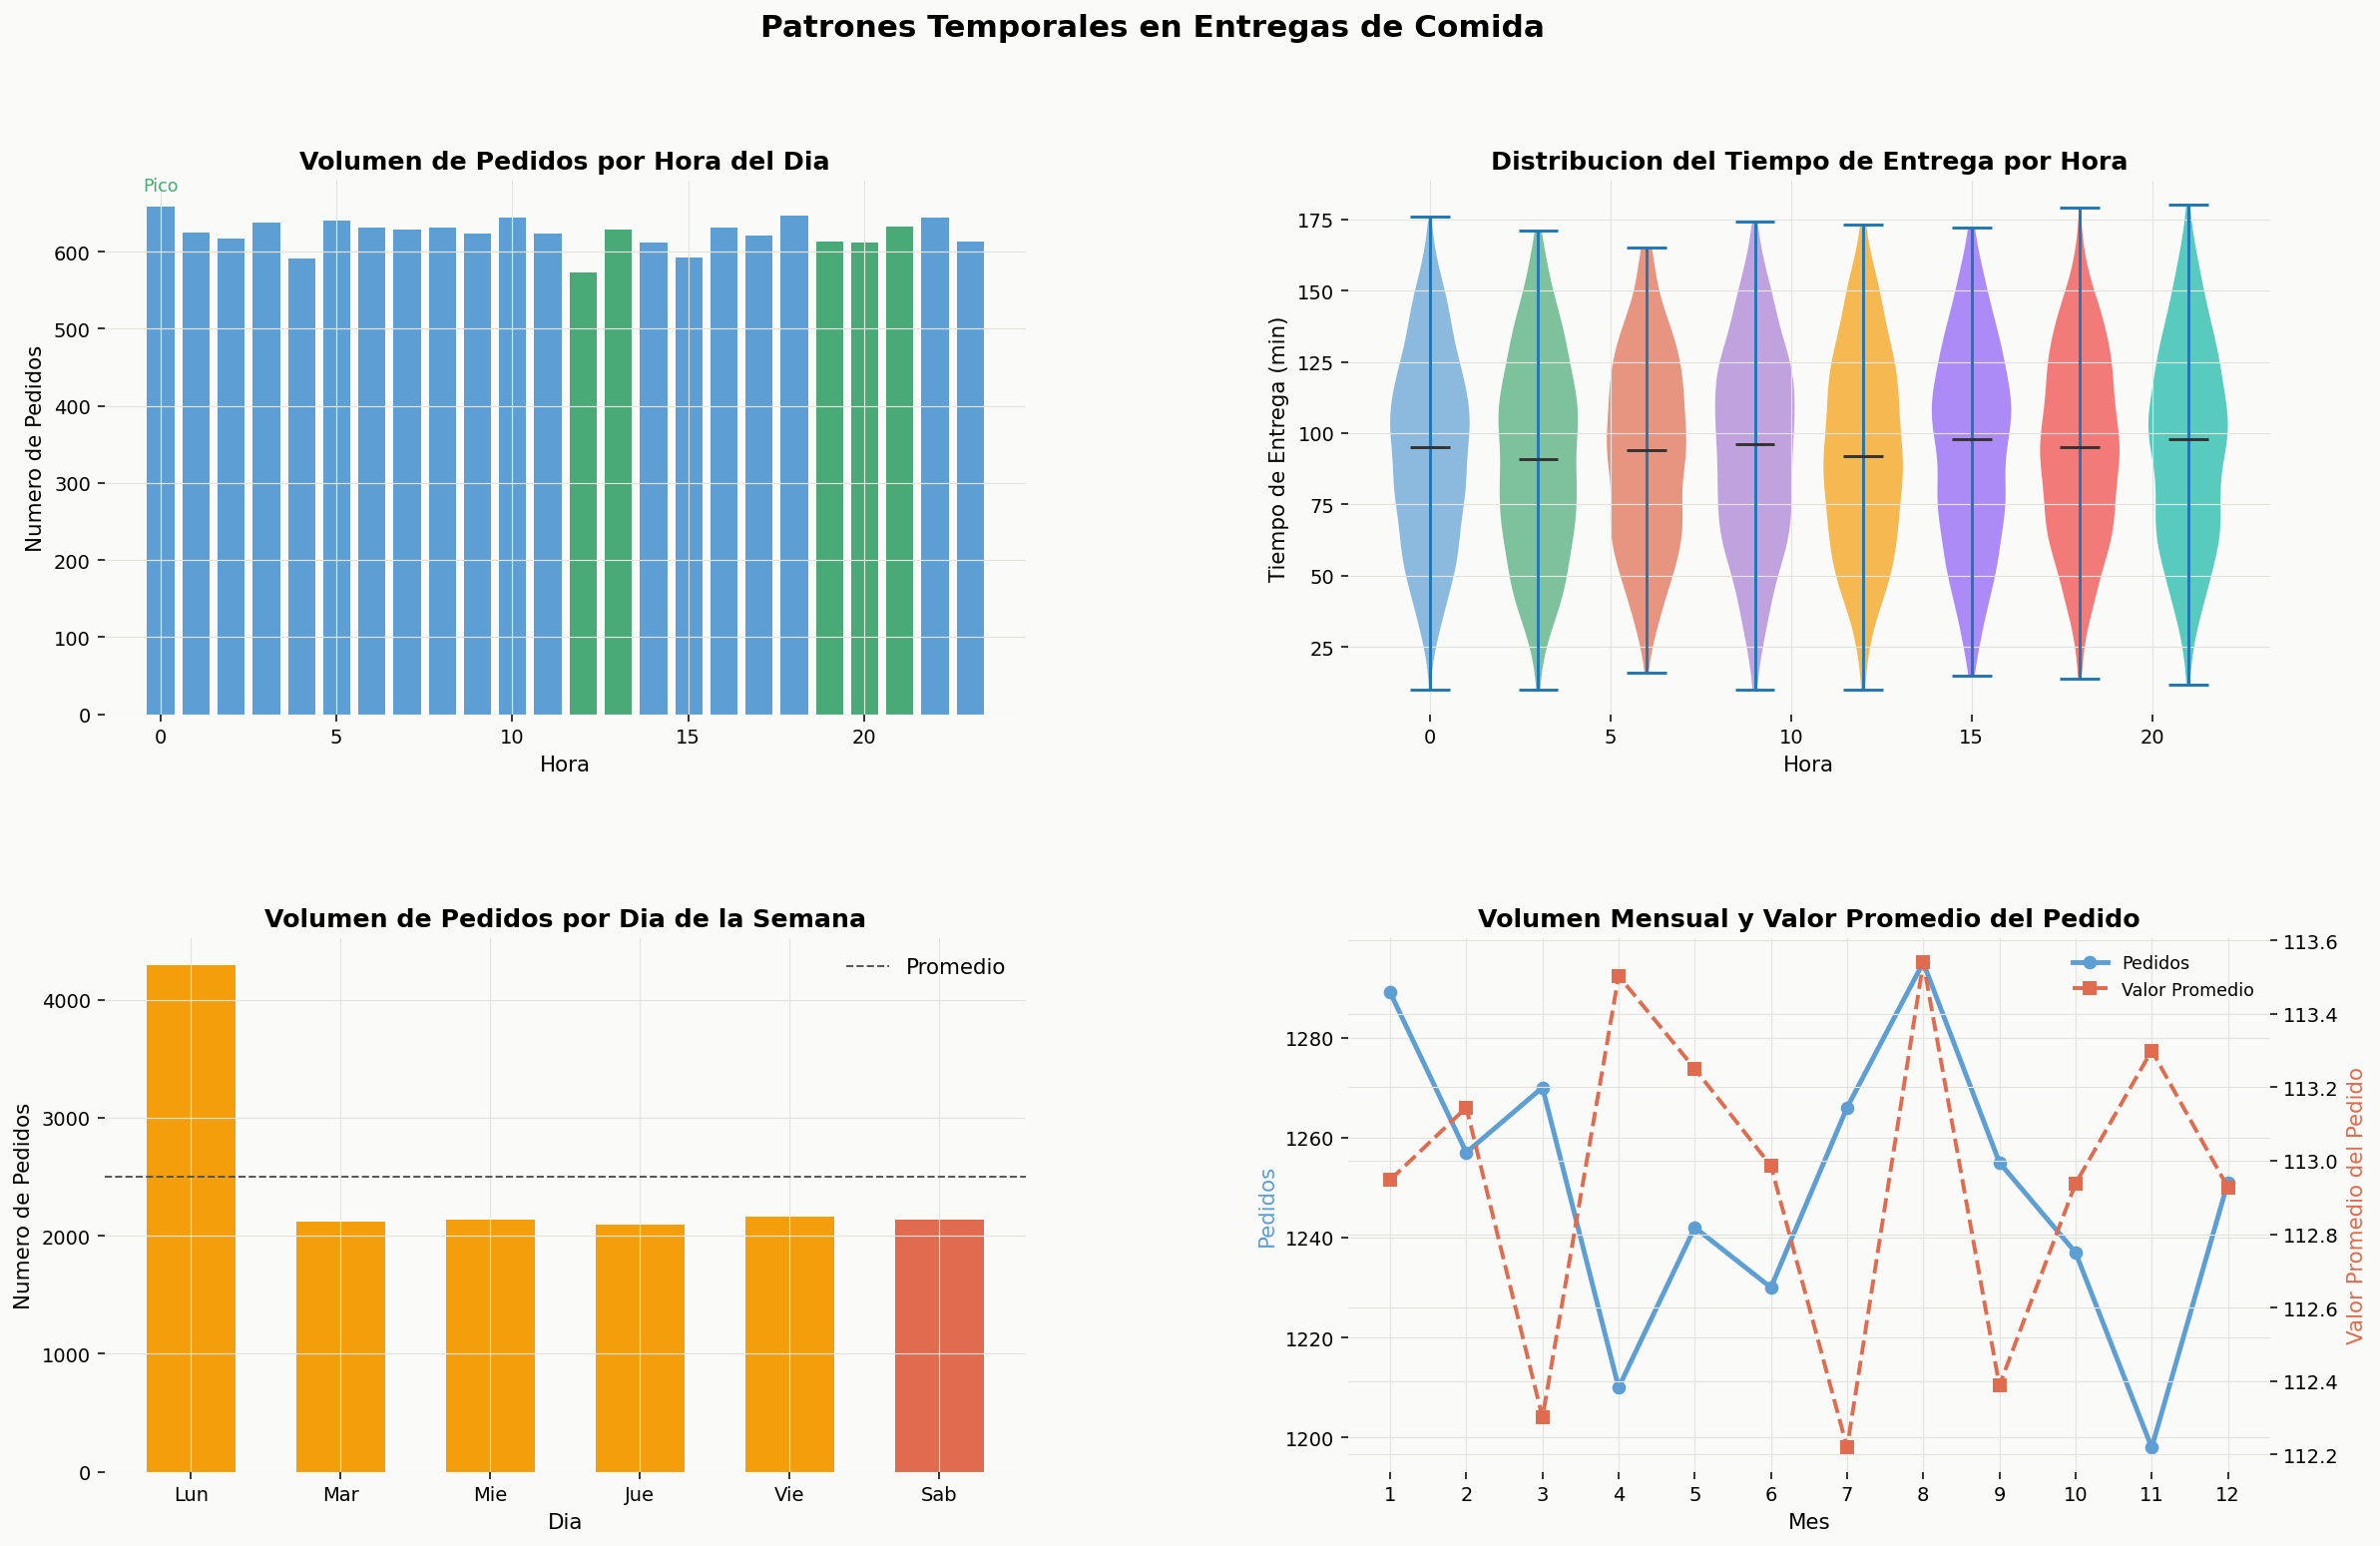

In [7]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Patrones Temporales en Entregas de Comida', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Volumen de pedidos por hora
ax1 = fig.add_subplot(gs[0, 0])
hourly = df.groupby('order_hour')['order_id'].count()
colors_h = [COLORS[1] if (h in [12,13,19,20,21]) else COLORS[0] for h in hourly.index]
bars = ax1.bar(hourly.index, hourly.values, color=colors_h, edgecolor='white', linewidth=0.5)
ax1.set_title('Volumen de Pedidos por Hora del Dia')
ax1.set_xlabel('Hora'); ax1.set_ylabel('Numero de Pedidos')
peak_h = hourly.idxmax()
ax1.annotate('Pico', xy=(peak_h, hourly.max()),
             xytext=(0,8), textcoords='offset points', ha='center', fontsize=9, color=COLORS[1])

# ── Tiempo de entrega por hora (violin)
ax2 = fig.add_subplot(gs[0, 1])
hour_data = [df[df['order_hour']==h]['delivery_time_minutes'].values for h in range(0,24,3)]
vp = ax2.violinplot(hour_data, positions=range(0,24,3), widths=2.2, showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(COLORS[i % len(COLORS)])
    body.set_alpha(0.7)
vp['cmedians'].set_color('#333')
ax2.set_title('Distribucion del Tiempo de Entrega por Hora')
ax2.set_xlabel('Hora'); ax2.set_ylabel('Tiempo de Entrega (min)')

# ── Volumen por dia de la semana
ax3 = fig.add_subplot(gs[1, 0])
days_map = {1:'Lun',2:'Mar',3:'Mie',4:'Jue',5:'Vie',6:'Sab'}
daily = df.groupby('order_day_of_week')['order_id'].count()
daily.index = [days_map.get(d, str(int(d))) for d in daily.index]
palette_days = [COLORS[2] if d in ['Sab','Dom'] else COLORS[4] for d in daily.index]
ax3.bar(daily.index, daily.values, color=palette_days, edgecolor='white', linewidth=0.5, width=0.6)
ax3.set_title('Volumen de Pedidos por Dia de la Semana')
ax3.set_xlabel('Dia'); ax3.set_ylabel('Numero de Pedidos')
ax3.axhline(daily.mean(), color='#555', linestyle='--', linewidth=1, label='Promedio')
ax3.legend(frameon=False)

# ── Tendencia mensual
ax4 = fig.add_subplot(gs[1, 1])
monthly = df.groupby('order_month').agg(
    pedidos=('order_id','count'),
    valor_promedio=('order_value','mean'),
).reset_index()
ax4_twin = ax4.twinx()
ax4.plot(monthly['order_month'], monthly['pedidos'], color=COLORS[0], linewidth=2.5, marker='o', label='Pedidos')
ax4_twin.plot(monthly['order_month'], monthly['valor_promedio'], color=COLORS[2], linewidth=2, linestyle='--', marker='s', label='Valor Promedio')
ax4.set_title('Volumen Mensual y Valor Promedio del Pedido')
ax4.set_xlabel('Mes'); ax4.set_ylabel('Pedidos', color=COLORS[0])
ax4_twin.set_ylabel('Valor Promedio del Pedido', color=COLORS[2])
ax4.set_xticks(monthly['order_month'])
lines1, lab1 = ax4.get_legend_handles_labels()
lines2, lab2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, lab1+lab2, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

---
# § 04 — Física de la entrega: distancia, tiempo y eficiencia

Detrás de cada pedido hay un recorrido físico. Cómo la distancia determina el tiempo, y qué separa a un repartidor élite de uno promedio.

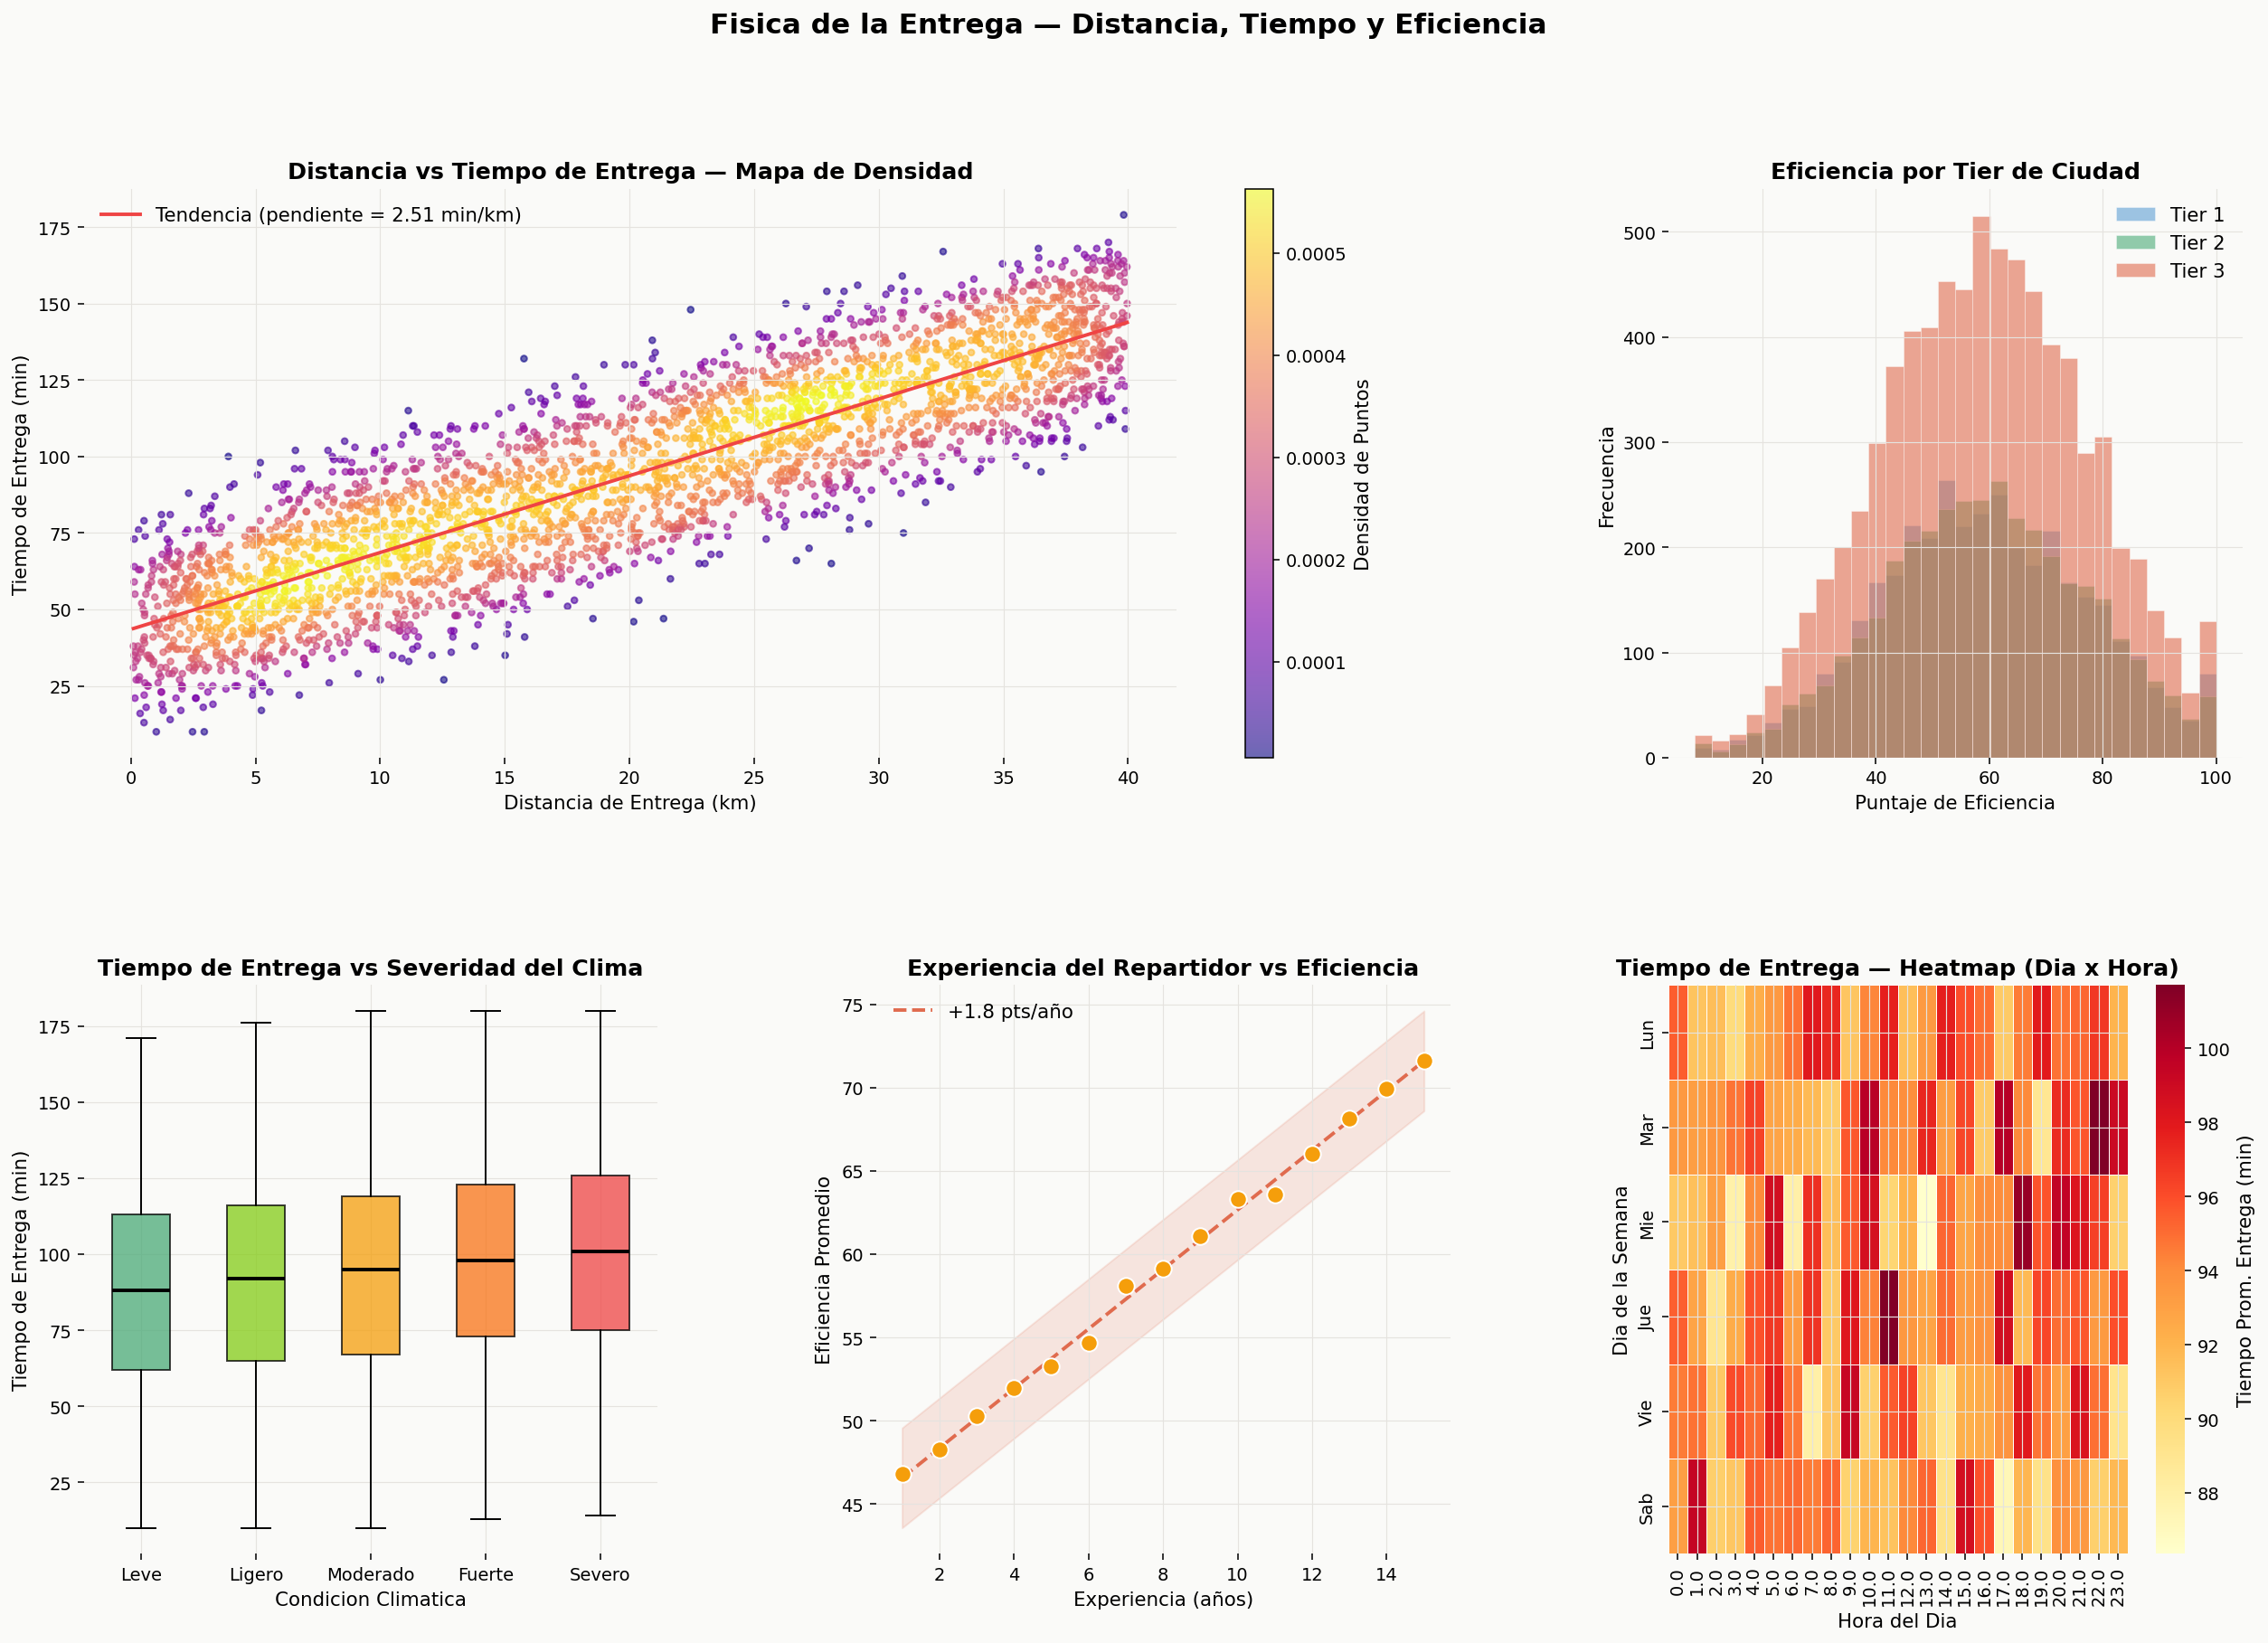

In [8]:
fig = plt.figure(figsize=(22, 14))
fig.suptitle('Fisica de la Entrega — Distancia, Tiempo y Eficiencia', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.38)

# ── Scatter: Distancia vs Tiempo (coloreado por densidad)
ax1 = fig.add_subplot(gs[0, :2])
sample = df.sample(3000, random_state=42)
xy = np.vstack([sample['delivery_distance_km'], sample['delivery_time_minutes']])
z  = gaussian_kde(xy)(xy)
sc = ax1.scatter(sample['delivery_distance_km'], sample['delivery_time_minutes'],
                 c=z, cmap='plasma', s=12, alpha=0.6)
plt.colorbar(sc, ax=ax1, label='Densidad de Puntos')
m, b = np.polyfit(sample['delivery_distance_km'], sample['delivery_time_minutes'], 1)
xs   = np.linspace(sample['delivery_distance_km'].min(), sample['delivery_distance_km'].max(), 200)
ax1.plot(xs, m*xs+b, color='#ef4444', linewidth=2, label=f'Tendencia (pendiente = {m:.2f} min/km)')
ax1.set_title('Distancia vs Tiempo de Entrega — Mapa de Densidad')
ax1.set_xlabel('Distancia de Entrega (km)'); ax1.set_ylabel('Tiempo de Entrega (min)')
ax1.legend(frameon=False)

# ── Eficiencia por tier de ciudad
ax2 = fig.add_subplot(gs[0, 2])
for tier, color in zip([1,2,3], COLORS[:3]):
    data = df[df['city_tier']==tier]['delivery_efficiency_score']
    ax2.hist(data, bins=30, alpha=0.6, color=color, label=f'Tier {int(tier)}', edgecolor='white', linewidth=0.3)
ax2.set_title('Eficiencia por Tier de Ciudad')
ax2.set_xlabel('Puntaje de Eficiencia'); ax2.set_ylabel('Frecuencia')
ax2.legend(frameon=False)

# ── Boxplot: Tiempo de entrega vs clima
ax3 = fig.add_subplot(gs[1, 0])
weather_order = ['Leve','Ligero','Moderado','Fuerte','Severo']
bp_data = [df[df['weather_bucket']==w]['delivery_time_minutes'].dropna() for w in weather_order]
bp = ax3.boxplot(bp_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
weather_colors_list = ['#4aaa77','#84cc16','#f59e0b','#f97316','#ef4444']
for patch, color in zip(bp['boxes'], weather_colors_list):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax3.set_xticklabels(weather_order)
ax3.set_title('Tiempo de Entrega vs Severidad del Clima')
ax3.set_xlabel('Condicion Climatica'); ax3.set_ylabel('Tiempo de Entrega (min)')

# ── Experiencia del repartidor vs eficiencia
ax4 = fig.add_subplot(gs[1, 1])
exp_eff = df.groupby('delivery_partner_experience_years')['delivery_efficiency_score'].mean().reset_index()
ax4.scatter(exp_eff['delivery_partner_experience_years'], exp_eff['delivery_efficiency_score'],
            s=90, color=COLORS[4], zorder=5, edgecolors='white', linewidth=1)
m2, b2 = np.polyfit(exp_eff['delivery_partner_experience_years'], exp_eff['delivery_efficiency_score'], 1)
xs2 = np.linspace(exp_eff['delivery_partner_experience_years'].min(),
                  exp_eff['delivery_partner_experience_years'].max(), 100)
ax4.plot(xs2, m2*xs2+b2, color=COLORS[2], linewidth=2, linestyle='--', label=f'+{m2:.1f} pts/año')
ax4.fill_between(xs2, m2*xs2+b2-3, m2*xs2+b2+3, alpha=0.15, color=COLORS[2])
ax4.set_title('Experiencia del Repartidor vs Eficiencia')
ax4.set_xlabel('Experiencia (años)'); ax4.set_ylabel('Eficiencia Promedio')
ax4.legend(frameon=False)

# ── Heatmap: Hora x Dia — tiempo promedio de entrega
ax5 = fig.add_subplot(gs[1, 2])
heatmap_data = df.pivot_table(values='delivery_time_minutes', index='order_day_of_week',
                               columns='order_hour', aggfunc='mean')
sns.heatmap(heatmap_data, ax=ax5, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Tiempo Prom. Entrega (min)'},
            yticklabels=['Lun','Mar','Mie','Jue','Vie','Sab'])
ax5.set_title('Tiempo de Entrega — Heatmap (Dia x Hora)')
ax5.set_xlabel('Hora del Dia'); ax5.set_ylabel('Dia de la Semana')

plt.tight_layout()
plt.show()

In [9]:
# Estadisticas clave — Fisica de la Entrega
corr_dist_time, _ = pearsonr(df['delivery_distance_km'].dropna(), df['delivery_time_minutes'].dropna())
exp_min = df[df['delivery_partner_experience_years'] <= 1]['delivery_efficiency_score'].mean()
exp_max = df[df['delivery_partner_experience_years'] >= 14]['delivery_efficiency_score'].mean()

weather_time = df.groupby('weather_bucket')['delivery_time_minutes'].mean()

print('='*55)
print('  ESTADISTICAS CLAVE — FISICA DE LA ENTREGA')
print('='*55)
print(f'  Correlacion distancia-tiempo  : {corr_dist_time:.3f}')
print(f'  Eficiencia repartidores nuevos: {exp_min:.1f} pts')
print(f'  Eficiencia repartidores senior: {exp_max:.1f} pts')
print(f'  Brecha de experiencia         : {(exp_max-exp_min)/exp_min*100:.1f}%')
print()
print('  Tiempo promedio por condicion climatica:')
for w, t in weather_time.items():
    print(f'    {w:<12}: {t:.1f} min')
print('='*55)

  ESTADISTICAS CLAVE — FISICA DE LA ENTREGA
  Correlacion distancia-tiempo  : 0.864
  Eficiencia repartidores nuevos: 46.8 pts
  Eficiencia repartidores senior: 70.8 pts
  Brecha de experiencia         : 51.4%

  Tiempo promedio por condicion climatica:
    Leve        : 87.7 min
    Ligero      : 91.1 min
    Moderado    : 94.0 min
    Fuerte      : 97.7 min
    Severo      : 100.4 min


---
# § 05 — Economía del pedido

Revenue, descuentos, tarifas y propinas: la anatomía financiera de cada entrega.

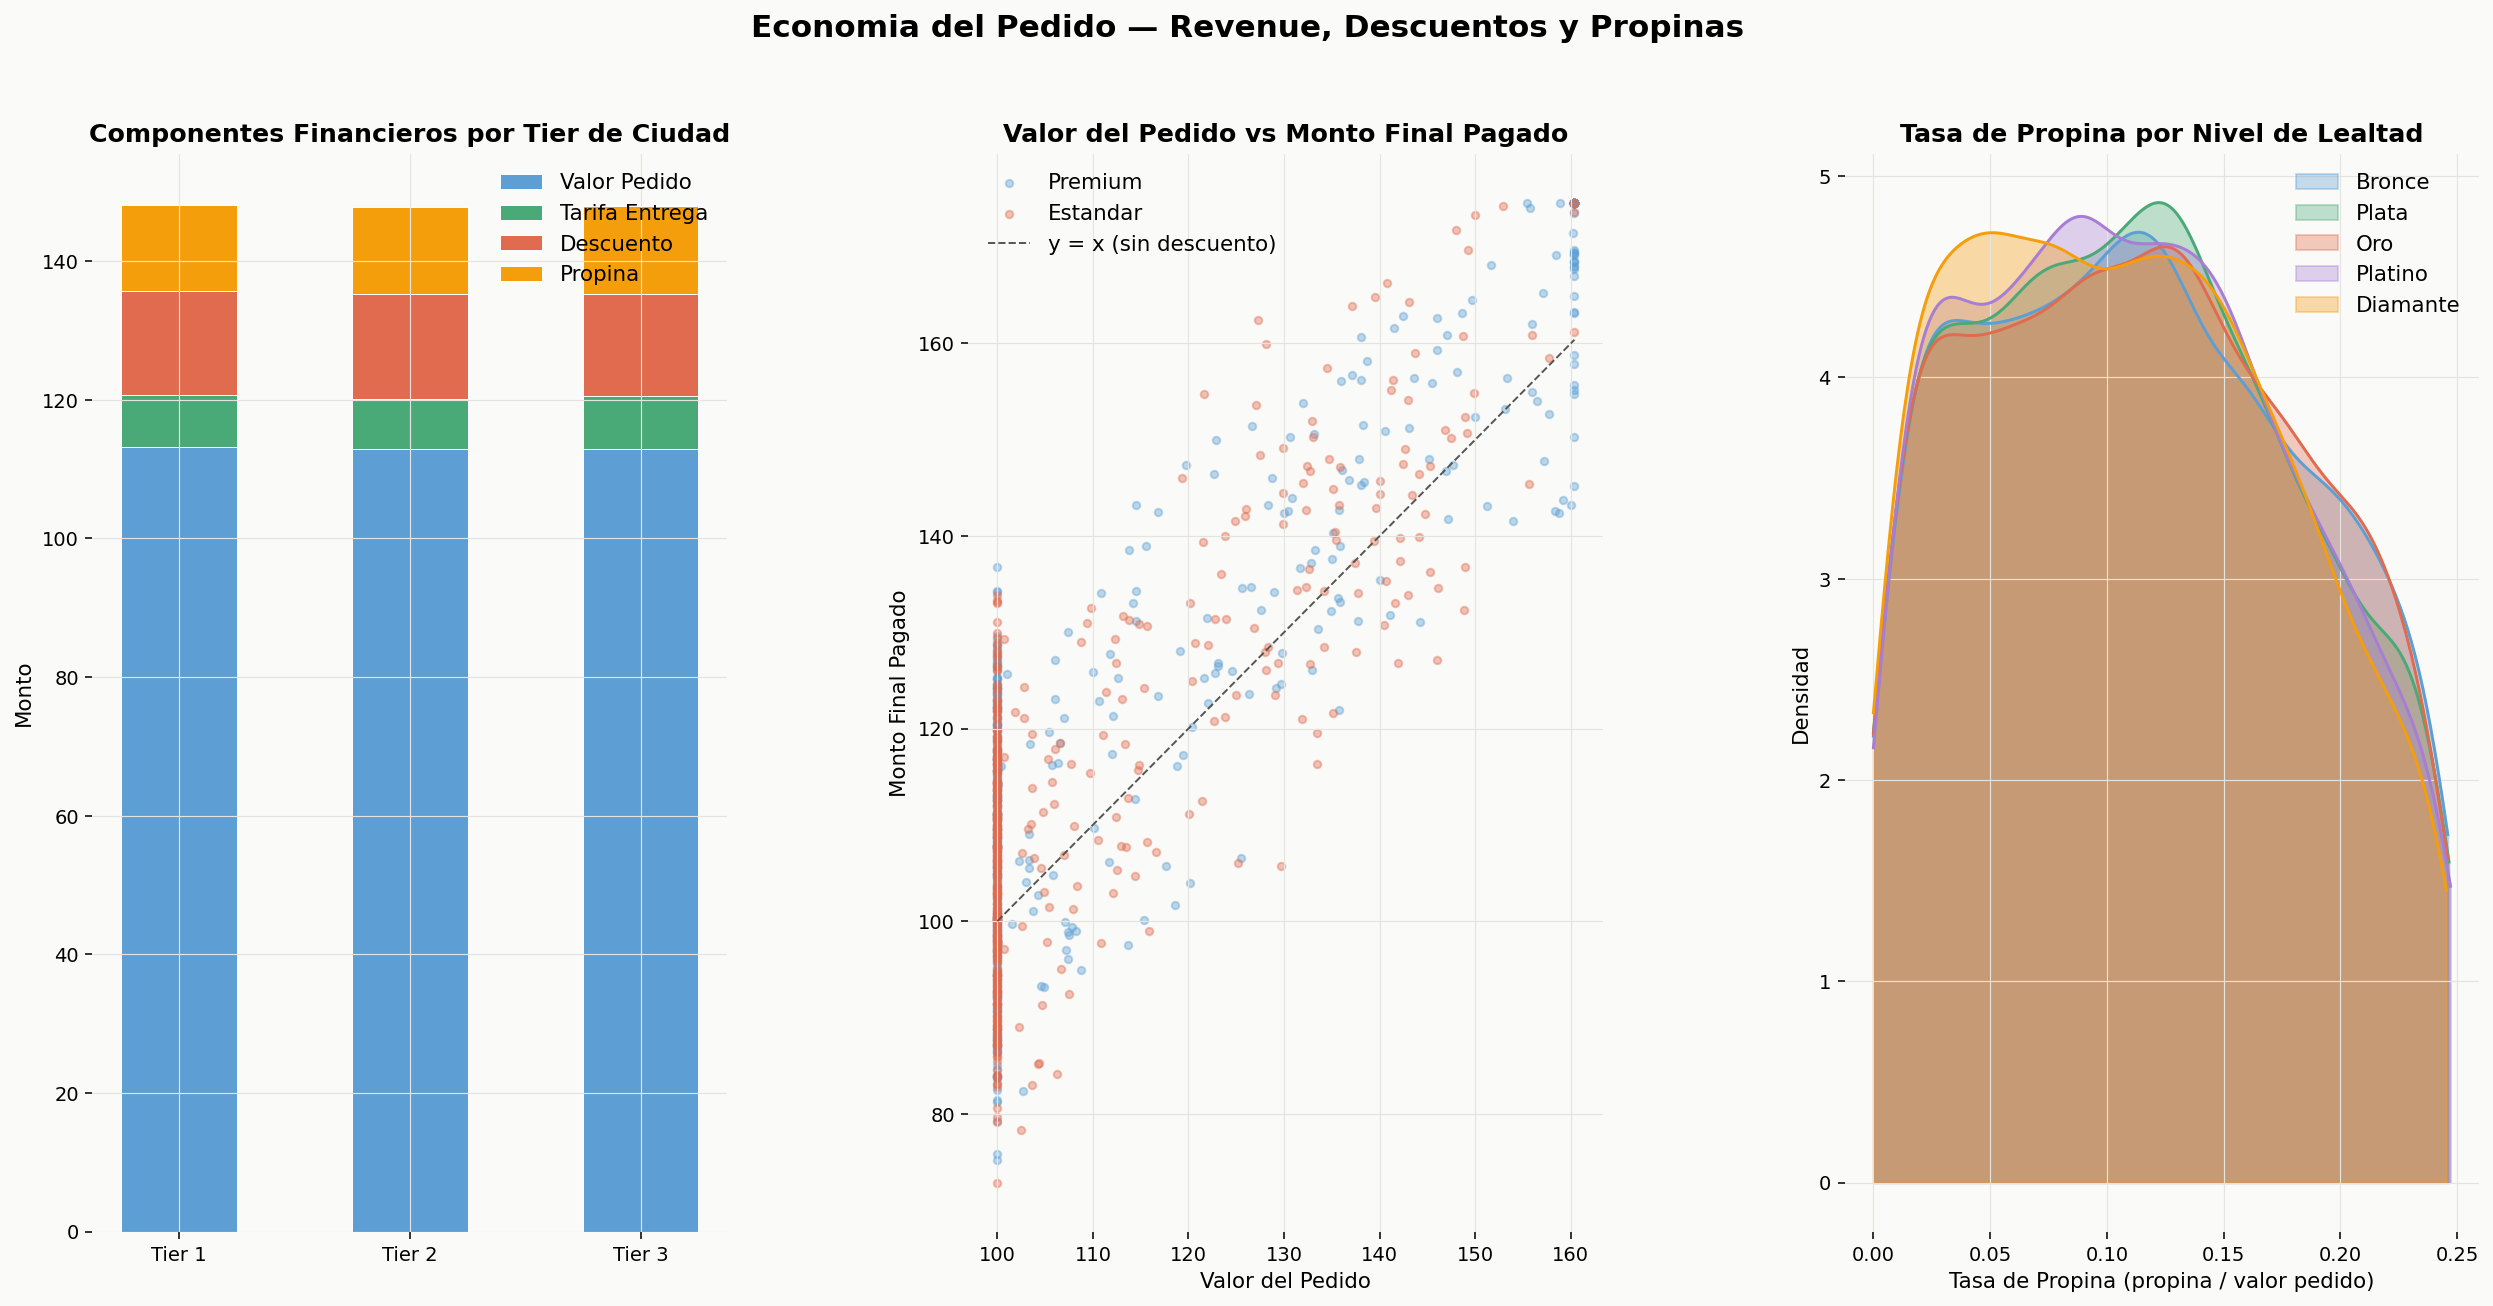

In [10]:
fig = plt.figure(figsize=(22, 10))
fig.suptitle('Economia del Pedido — Revenue, Descuentos y Propinas', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Barras apiladas: componentes financieros por tier de ciudad
ax1 = fig.add_subplot(gs[0])
econ = df.groupby('city_tier')[['order_value','delivery_fee','discount_amount','tip_amount']].mean()
bottom = np.zeros(len(econ))
comp_colors = [COLORS[0], COLORS[1], COLORS[2], COLORS[4]]
labels_bar  = ['Valor Pedido','Tarifa Entrega','Descuento','Propina']
tiers_labels = [f'Tier {int(t)}' for t in econ.index]
for col, color, label in zip(econ.columns, comp_colors, labels_bar):
    ax1.bar(tiers_labels, econ[col], bottom=bottom, color=color, label=label,
            edgecolor='white', linewidth=0.5, width=0.5)
    bottom += econ[col].values
ax1.set_title('Componentes Financieros por Tier de Ciudad')
ax1.set_ylabel('Monto'); ax1.legend(loc='upper right', frameon=False)

# ── Scatter: Valor del pedido vs monto final pagado (premium vs estandar)
ax2 = fig.add_subplot(gs[1])
for flag, color, label in [(True, COLORS[0], 'Premium'), (False, COLORS[2], 'Estandar')]:
    sub = df[df['premium_customer_flag']==flag].sample(500, random_state=1)
    ax2.scatter(sub['order_value'], sub['final_amount_paid'], c=color, alpha=0.4, s=15, label=label)
min_val = df['order_value'].min(); max_val = df['order_value'].max()
ax2.plot([min_val, max_val],[min_val, max_val], color='#555', linestyle='--', linewidth=1, label='y = x (sin descuento)')
ax2.set_title('Valor del Pedido vs Monto Final Pagado')
ax2.set_xlabel('Valor del Pedido'); ax2.set_ylabel('Monto Final Pagado')
ax2.legend(frameon=False)

# ── KDE: Distribucion de tasa de propina por tier de lealtad
ax3 = fig.add_subplot(gs[2])
loyalty_order = ['Bronce','Plata','Oro','Platino','Diamante']
for tier, color in zip(loyalty_order, COLORS[:5]):
    data = df[df['loyalty_tier']==tier]['tip_rate'].dropna()
    if len(data) > 10:
        kde = gaussian_kde(data)
        xs  = np.linspace(0, data.quantile(0.99), 300)
        ax3.fill_between(xs, kde(xs), alpha=0.35, color=color, label=tier)
        ax3.plot(xs, kde(xs), color=color, linewidth=1.5)
ax3.set_title('Tasa de Propina por Nivel de Lealtad')
ax3.set_xlabel('Tasa de Propina (propina / valor pedido)'); ax3.set_ylabel('Densidad')
ax3.legend(frameon=False)

plt.tight_layout()
plt.show()

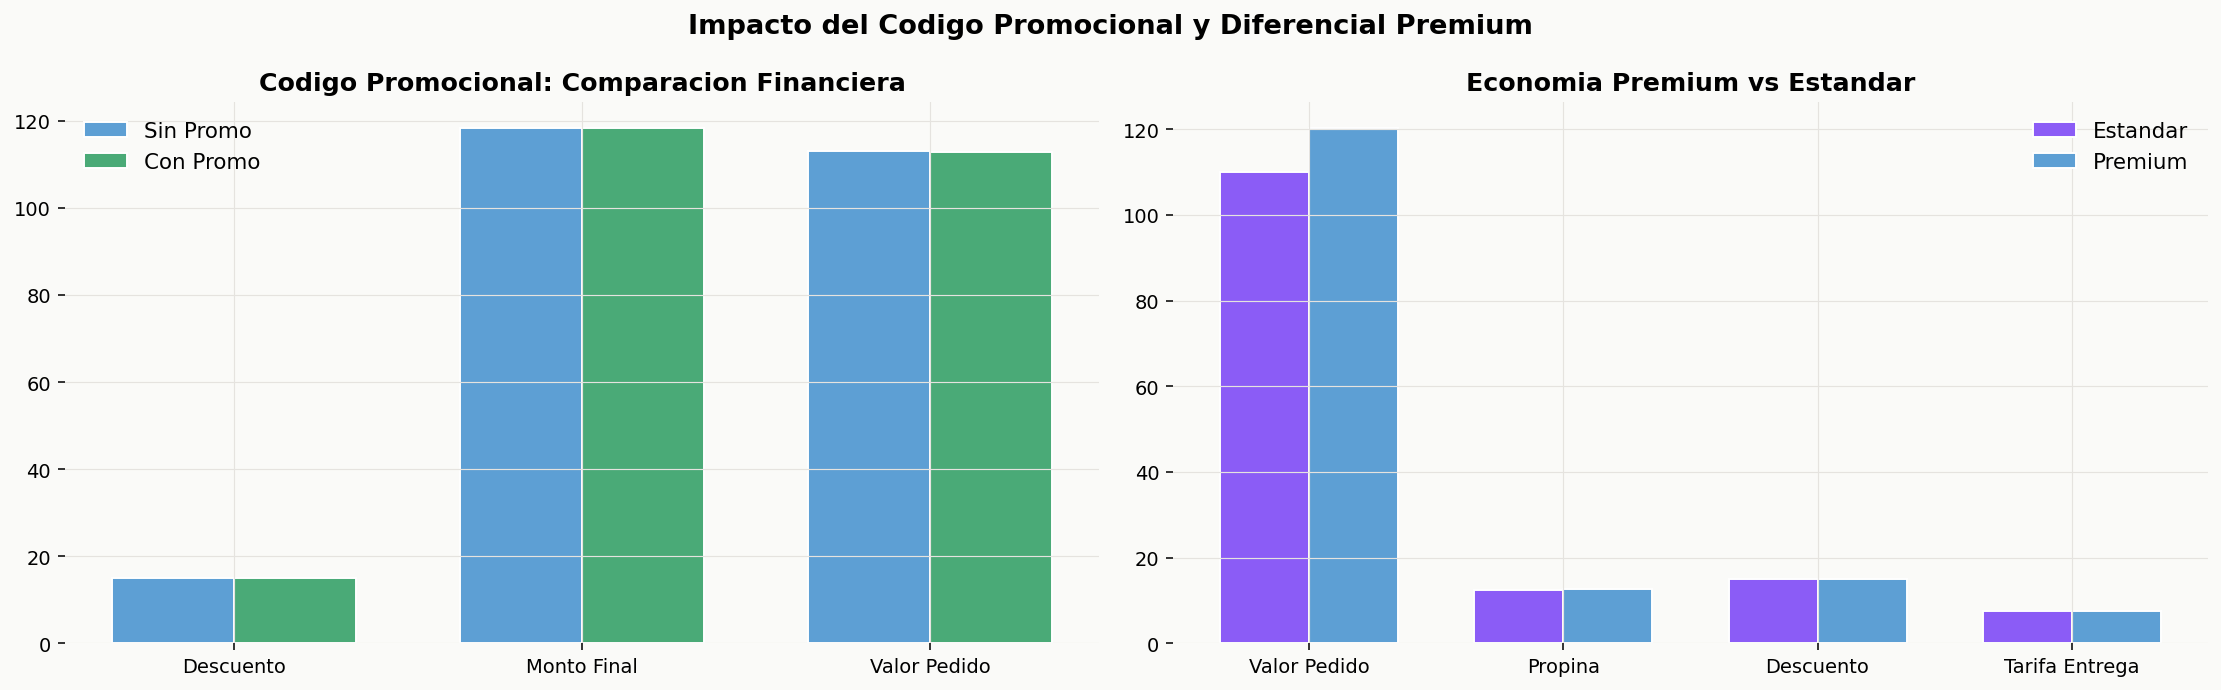

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Impacto del Codigo Promocional y Diferencial Premium', fontsize=14, fontweight='bold')

# ── Promo vs sin promo
promo_grp = df.groupby('promo_code_used')[['discount_amount','final_amount_paid','order_value']].mean()
x = np.arange(3); w = 0.35
axes[0].bar(x - w/2, promo_grp.loc[False], width=w, color=COLORS[0], label='Sin Promo', edgecolor='white')
axes[0].bar(x + w/2, promo_grp.loc[True],  width=w, color=COLORS[1], label='Con Promo', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Descuento','Monto Final','Valor Pedido'])
axes[0].set_title('Codigo Promocional: Comparacion Financiera')
axes[0].legend(frameon=False)

# ── Diferencial Premium
prem_grp = df.groupby('premium_customer_flag')[['order_value','tip_amount','discount_amount','delivery_fee']].mean()
categorias = ['Valor Pedido','Propina','Descuento','Tarifa Entrega']
axes[1].bar(np.arange(4) - w/2, prem_grp.loc[False], width=w, color=COLORS[5], label='Estandar', edgecolor='white')
axes[1].bar(np.arange(4) + w/2, prem_grp.loc[True],  width=w, color=COLORS[0], label='Premium',  edgecolor='white')
axes[1].set_xticks(np.arange(4)); axes[1].set_xticklabels(categorias)
axes[1].set_title('Economia Premium vs Estandar')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

---
# § 06 — Clientes y satisfacción

¿Quién ordena? ¿Cómo difieren en comportamiento y gasto? ¿Los clientes premium presentan mayor satisfacción?

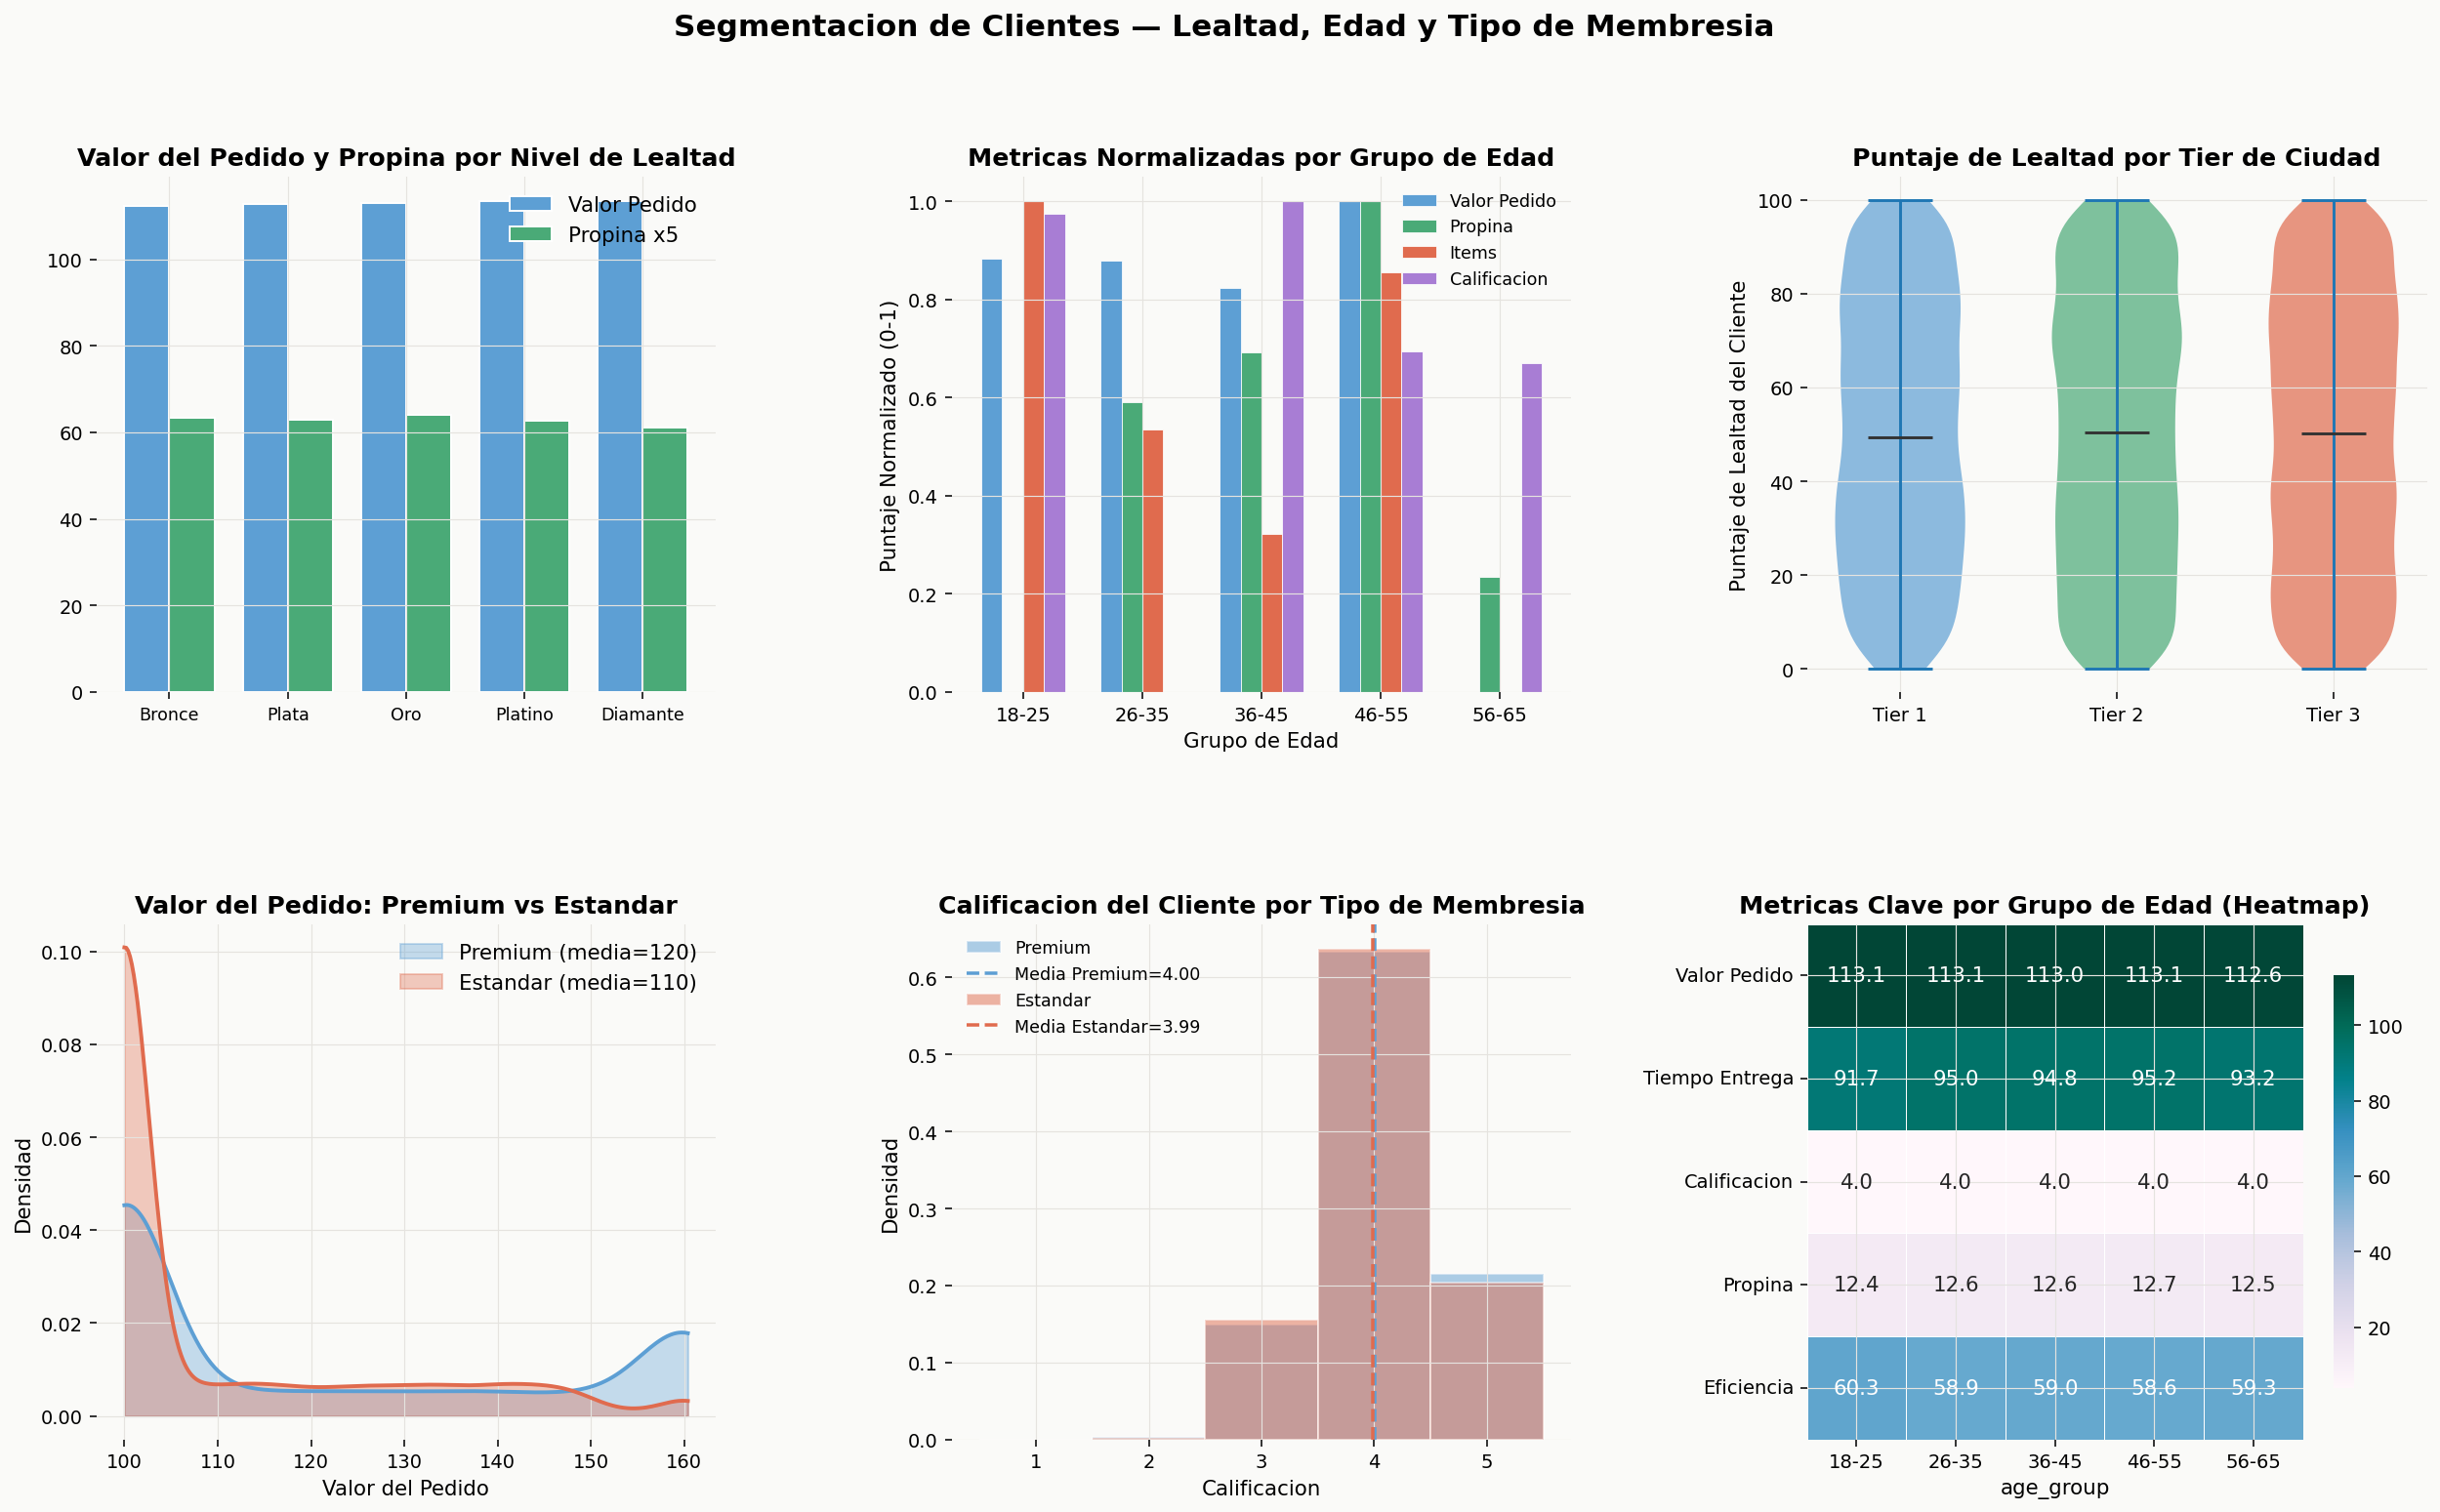

In [12]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Segmentacion de Clientes — Lealtad, Edad y Tipo de Membresia', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Lealtad: valor del pedido y propina
ax1 = fig.add_subplot(gs[0, 0])
loyalty_data = df.groupby('loyalty_tier')[['order_value','tip_amount']].mean()
x = np.arange(5); w = 0.38
ax1.bar(x - w/2, loyalty_data['order_value'], width=w, color=COLORS[0], label='Valor Pedido', edgecolor='white')
ax1.bar(x + w/2, loyalty_data['tip_amount']*5, width=w, color=COLORS[1], label='Propina x5', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(['Bronce','Plata','Oro','Platino','Diamante'], fontsize=9)
ax1.set_title('Valor del Pedido y Propina por Nivel de Lealtad')
ax1.legend(frameon=False)

# ── Grupo de edad: metricas normalizadas
ax2 = fig.add_subplot(gs[0, 1])
age_data = df.groupby('age_group')[['order_value','tip_amount','number_of_items','customer_rating']].mean()
age_data_norm = (age_data - age_data.min()) / (age_data.max() - age_data.min())
age_data_norm.plot(kind='bar', ax=ax2, color=COLORS[:4], edgecolor='white', linewidth=0.4, width=0.7)
ax2.set_title('Metricas Normalizadas por Grupo de Edad')
ax2.set_xlabel('Grupo de Edad'); ax2.set_ylabel('Puntaje Normalizado (0-1)')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['Valor Pedido','Propina','Items','Calificacion'], fontsize=9, frameon=False)

# ── Distribucion de lealtad por tier de ciudad (violin)
ax3 = fig.add_subplot(gs[0, 2])
tier_loyalty = [df[df['city_tier']==t]['customer_loyalty_score'].values for t in [1,2,3]]
vp = ax3.violinplot(tier_loyalty, positions=[1,2,3], showmedians=True, widths=0.6)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(COLORS[i]); body.set_alpha(0.7)
vp['cmedians'].set_color('#333')
ax3.set_xticks([1,2,3]); ax3.set_xticklabels(['Tier 1','Tier 2','Tier 3'])
ax3.set_title('Puntaje de Lealtad por Tier de Ciudad')
ax3.set_ylabel('Puntaje de Lealtad del Cliente')

# ── Premium: distribucion de valor del pedido
ax4 = fig.add_subplot(gs[1, 0])
for flag, color, label in [(True, COLORS[0], 'Premium'), (False, COLORS[2], 'Estandar')]:
    data = df[df['premium_customer_flag']==flag]['order_value']
    kde  = gaussian_kde(data)
    xs   = np.linspace(data.min(), data.max(), 300)
    ax4.fill_between(xs, kde(xs), alpha=0.35, color=color, label=f'{label} (media={data.mean():.0f})')
    ax4.plot(xs, kde(xs), color=color, linewidth=2)
ax4.set_title('Valor del Pedido: Premium vs Estandar')
ax4.set_xlabel('Valor del Pedido'); ax4.set_ylabel('Densidad')
ax4.legend(frameon=False)

# ── Calificacion del cliente: satisfaccion por tipo
ax5 = fig.add_subplot(gs[1, 1])
for flag, color, label in [(True, COLORS[0], 'Premium'), (False, COLORS[2], 'Estandar')]:
    data = df[df['premium_customer_flag']==flag]['customer_rating'].dropna()
    ax5.hist(data, bins=[0.5,1.5,2.5,3.5,4.5,5.5], density=True,
             color=color, alpha=0.5, edgecolor='white', label=label)
    ax5.axvline(data.mean(), color=color, linestyle='--', linewidth=1.8,
                label=f'Media {label}={data.mean():.2f}')
ax5.set_title('Calificacion del Cliente por Tipo de Membresia')
ax5.set_xlabel('Calificacion'); ax5.set_ylabel('Densidad')
ax5.legend(frameon=False, fontsize=9)

# ── Heatmap: metricas clave por grupo de edad
ax6 = fig.add_subplot(gs[1, 2])
age_heat = df.groupby('age_group')[['order_value','delivery_time_minutes','customer_rating',
                                     'tip_amount','delivery_efficiency_score']].mean()
age_heat.columns = ['Valor Pedido','Tiempo Entrega','Calificacion','Propina','Eficiencia']
sns.heatmap(age_heat.T, ax=ax6, cmap='PuBuGn', annot=True, fmt='.1f',
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
ax6.set_title('Metricas Clave por Grupo de Edad (Heatmap)')

plt.tight_layout()
plt.show()

In [13]:
# Prueba estadistica: calificacion premium vs estandar
prem_rat  = df[df['premium_customer_flag']==True]['customer_rating'].dropna().values
stand_rat = df[df['premium_customer_flag']==False]['customer_rating'].dropna().values

u_stat, p_mw = mannwhitneyu(prem_rat, stand_rat, alternative='greater')
pooled_std   = np.sqrt((stand_rat.std()**2 + prem_rat.std()**2) / 2)
cohens_d     = (prem_rat.mean() - stand_rat.mean()) / pooled_std if pooled_std > 0 else 0
diff_pct     = (prem_rat.mean() - stand_rat.mean()) / stand_rat.mean() * 100

print('='*55)
print('  EVIDENCIA ESTADISTICA — CLIENTES Y SATISFACCION')
print('='*55)
print(f'  Media Estandar : {stand_rat.mean():.4f}')
print(f'  Media Premium  : {prem_rat.mean():.4f}')
print(f'  Diferencia     : {prem_rat.mean()-stand_rat.mean():.4f}  ({diff_pct:+.1f}%)')
print(f'  Mann-Whitney U : {u_stat:.0f}')
print(f'  p-valor        : {p_mw:.2e}  ({"Significativo" if p_mw < 0.05 else "No significativo"})')
print(f"  Cohen's d      : {cohens_d:.4f}  (efecto {'alto' if abs(cohens_d)>0.5 else 'moderado' if abs(cohens_d)>0.2 else 'pequeno'})")
print('='*55)

  EVIDENCIA ESTADISTICA — CLIENTES Y SATISFACCION
  Media Estandar : 3.9906
  Media Premium  : 4.0026
  Diferencia     : 0.0120  (+0.3%)
  Mann-Whitney U : 23088487
  p-valor        : 7.70e-02  (No significativo)
  Cohen's d      : 0.0225  (efecto pequeno)


---
# § 07 — Riesgo operativo: cancelaciones, retrasos y reembolsos

Todo negocio tiene líneas de fractura. Aquí mapeamos las tres más importantes.

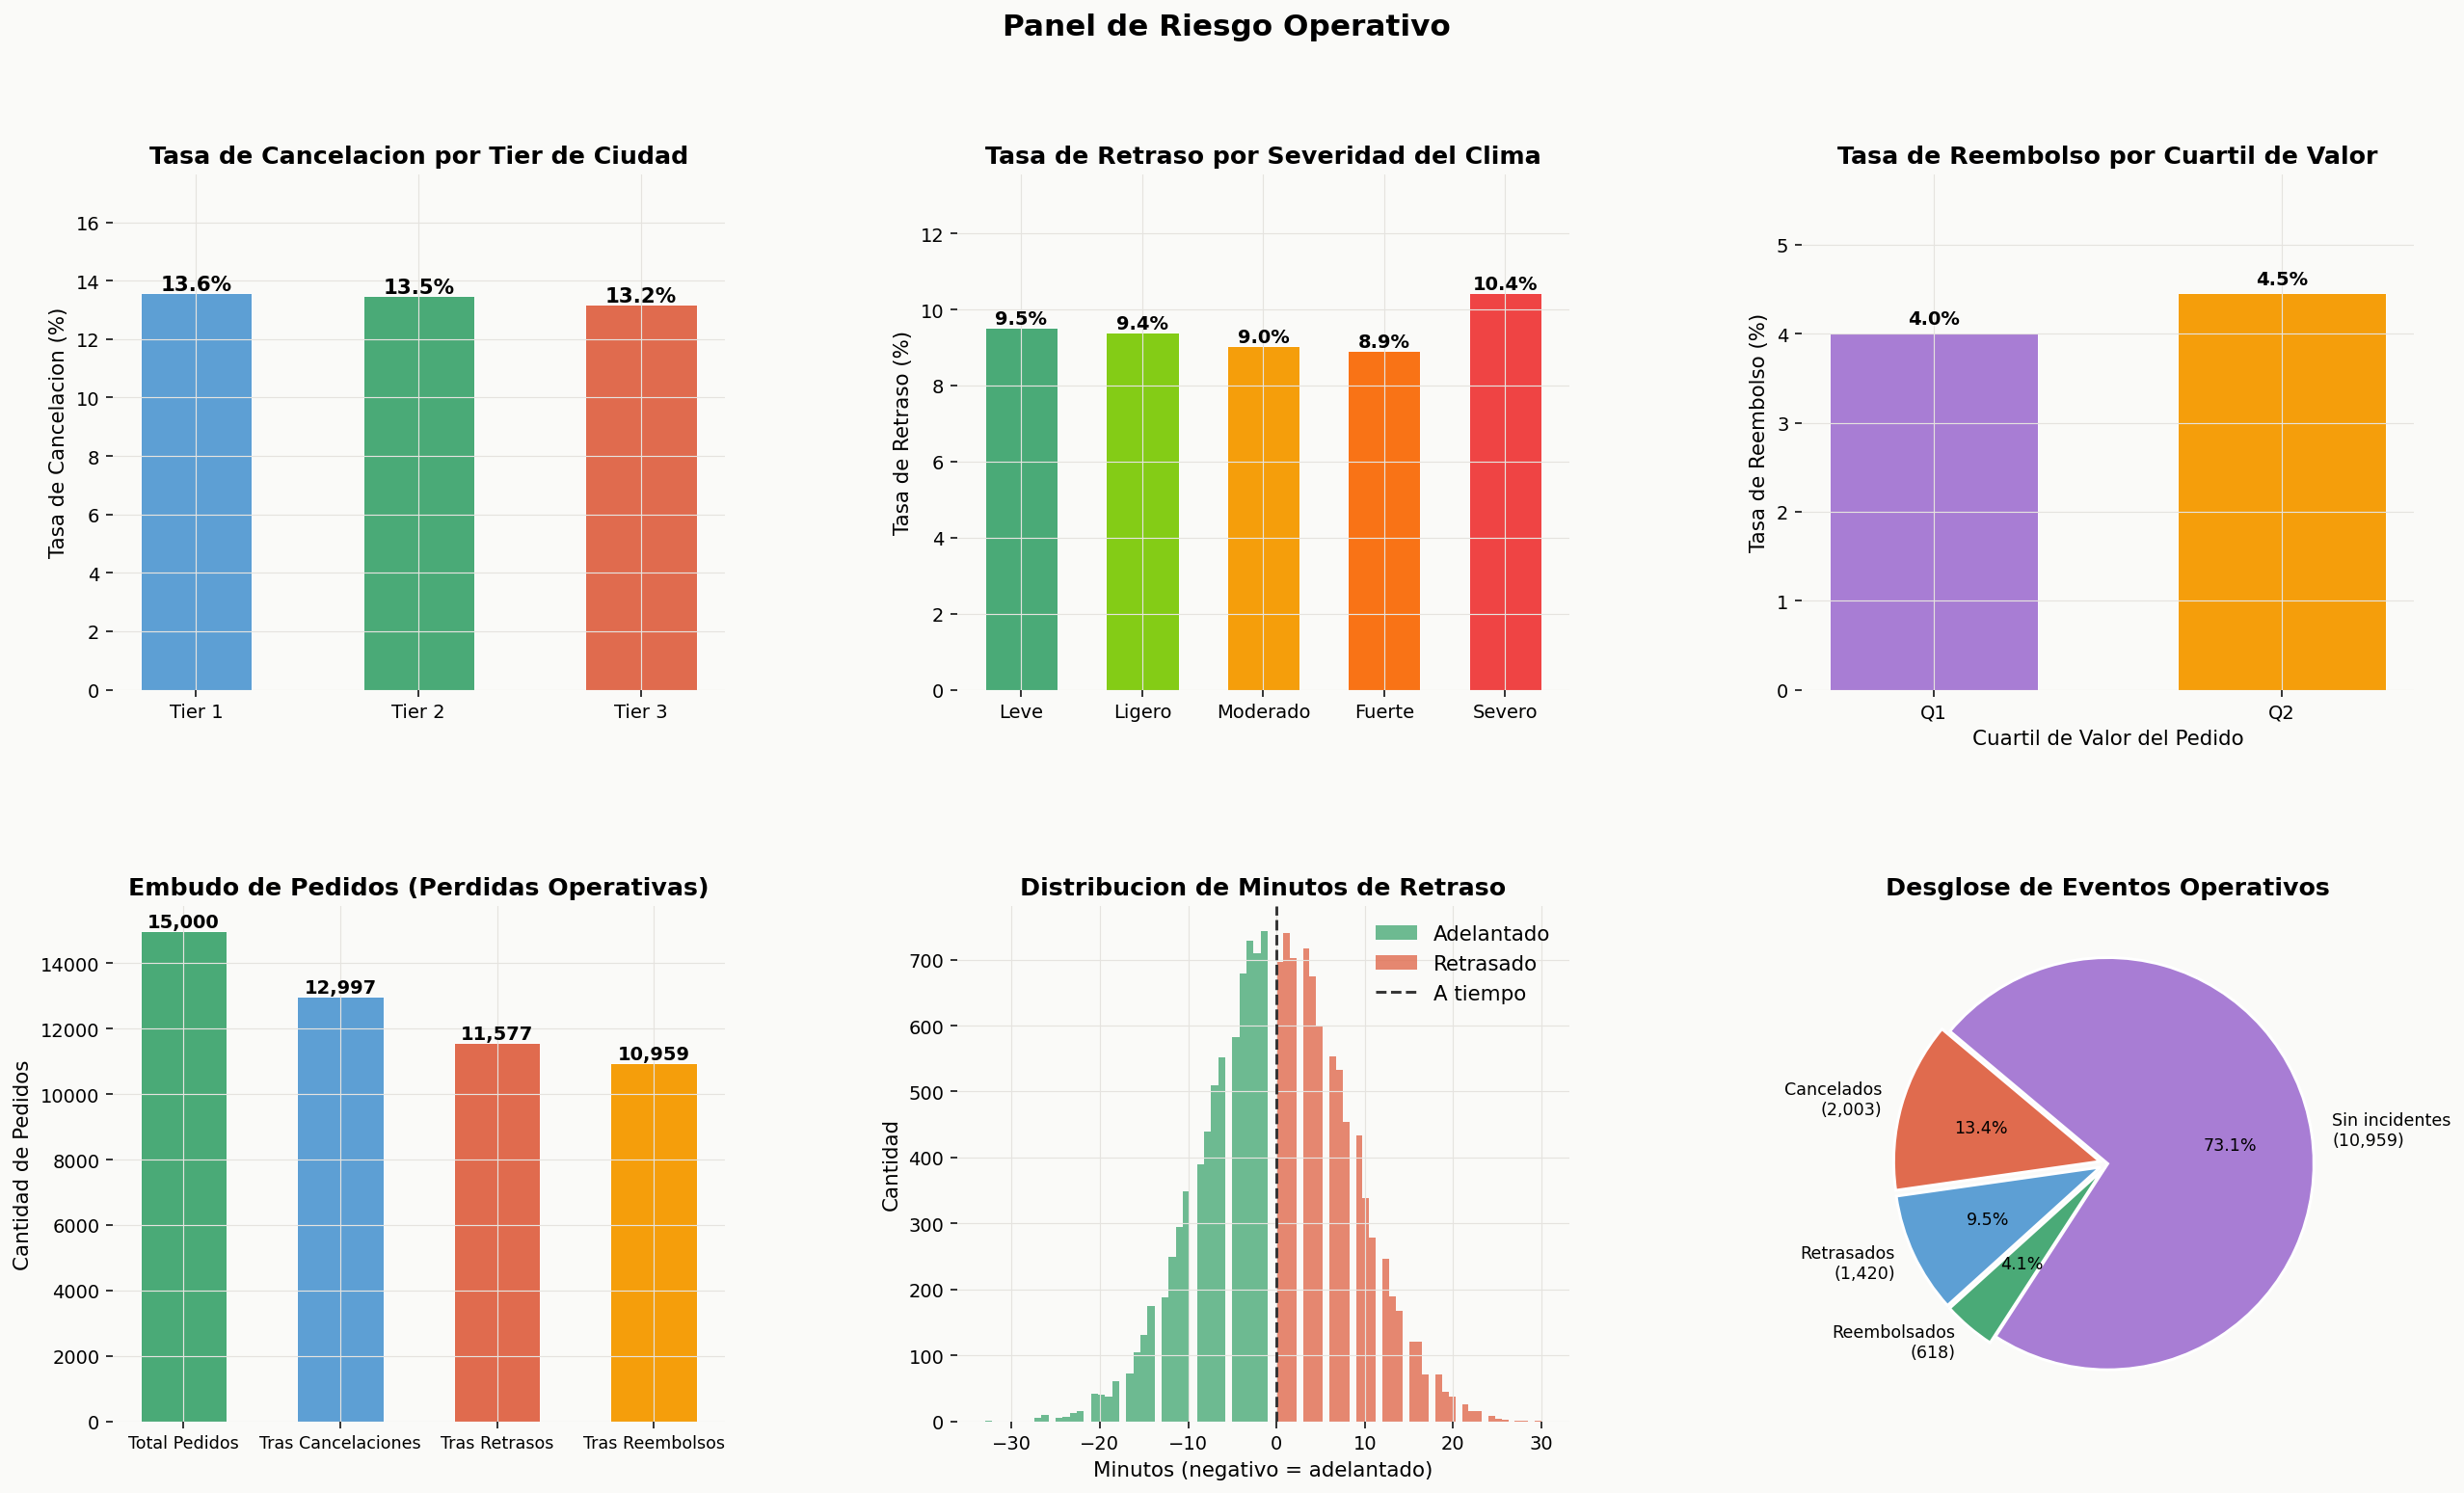

In [14]:
fig = plt.figure(figsize=(22, 12))
fig.suptitle('Panel de Riesgo Operativo', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ── Tasa de cancelacion por tier de ciudad
ax1 = fig.add_subplot(gs[0, 0])
cancel_rate = df.groupby('city_tier')['cancellation_flag'].mean() * 100
tiers_labels = [f'Tier {int(t)}' for t in cancel_rate.index]
bars = ax1.bar(tiers_labels, cancel_rate, color=COLORS[:3], edgecolor='white', linewidth=0.5, width=0.5)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Tasa de Cancelacion por Tier de Ciudad')
ax1.set_ylabel('Tasa de Cancelacion (%)')
ax1.set_ylim(0, cancel_rate.max()*1.3)

# ── Tasa de retraso por clima
ax2 = fig.add_subplot(gs[0, 1])
weather_delay = df.groupby('weather_bucket')['delayed_delivery_flag'].mean() * 100
valid_weather = [w for w in ['Leve','Ligero','Moderado','Fuerte','Severo'] if w in weather_delay.index]
vals_delay = [weather_delay[w] for w in valid_weather]
bars2 = ax2.bar(valid_weather, vals_delay,
                color=weather_colors_list[:len(valid_weather)], edgecolor='white', linewidth=0.5, width=0.6)
for bar in bars2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Tasa de Retraso por Severidad del Clima')
ax2.set_ylabel('Tasa de Retraso (%)')
ax2.set_ylim(0, max(vals_delay)*1.3 if vals_delay else 10)

# ── Tasa de reembolso por cuartil de valor del pedido
ax3 = fig.add_subplot(gs[0, 2])
df['order_value_q'] = pd.qcut(df['order_value'], q=4, duplicates='drop')
refund_q = df.groupby('order_value_q')['refund_flag'].mean() * 100
labels_q = [f'Q{i+1}' for i in range(len(refund_q.index))]
bars3 = ax3.bar(labels_q, refund_q.values, color=COLORS[3:3+len(labels_q)],
                edgecolor='white', linewidth=0.5, width=0.6)
for bar in bars3:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Tasa de Reembolso por Cuartil de Valor')
ax3.set_ylabel('Tasa de Reembolso (%)')
ax3.set_xlabel('Cuartil de Valor del Pedido')
ax3.set_ylim(0, refund_q.max()*1.3)

# ── Embudo de pedidos (waterfall)
ax4 = fig.add_subplot(gs[1, 0])
total     = len(df)
cancelled = df['cancellation_flag'].sum()
delayed   = df['delayed_delivery_flag'].sum()
refunded  = df['refund_flag'].sum()
labels_wf = ['Total Pedidos','Tras Cancelaciones','Tras Retrasos','Tras Reembolsos']
values_wf = [total, total-cancelled, total-cancelled-delayed, total-cancelled-delayed-refunded]
bars4 = ax4.bar(labels_wf, values_wf, color=[COLORS[1],COLORS[0],COLORS[2],COLORS[4]],
                edgecolor='white', linewidth=0.5, width=0.55)
for i, v in enumerate(values_wf):
    ax4.text(i, v+100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax4.set_title('Embudo de Pedidos (Perdidas Operativas)')
ax4.set_ylabel('Cantidad de Pedidos')
ax4.tick_params(axis='x', labelsize=9)

# ── Distribucion de minutos de retraso
ax5 = fig.add_subplot(gs[1, 1])
delay_vals = df['delivery_delay_minutes']
ax5.hist(delay_vals[delay_vals < 0], bins=40, color=COLORS[1], alpha=0.8, label='Adelantado')
ax5.hist(delay_vals[delay_vals >= 0], bins=40, color=COLORS[2], alpha=0.8, label='Retrasado')
ax5.axvline(0, color='#333', linestyle='--', linewidth=1.5, label='A tiempo')
ax5.set_title('Distribucion de Minutos de Retraso')
ax5.set_xlabel('Minutos (negativo = adelantado)')
ax5.set_ylabel('Cantidad')
ax5.legend(frameon=False)

# ── Torta: desglose de eventos de riesgo
ax6 = fig.add_subplot(gs[1, 2])
clean_orders = total - cancelled - delayed - refunded
sizes_pie = [cancelled, delayed, refunded, clean_orders]
labels_pie = [
    f'Cancelados\n({cancelled:,})',
    f'Retrasados\n({delayed:,})',
    f'Reembolsados\n({refunded:,})',
    f'Sin incidentes\n({clean_orders:,})'
]
explode = [0.04, 0.04, 0.04, 0]
wedge_colors = [COLORS[2], COLORS[0], COLORS[1], COLORS[3]]
ax6.pie(sizes_pie, labels=labels_pie, colors=wedge_colors, explode=explode,
        autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 9},
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
ax6.set_title('Desglose de Eventos Operativos')

plt.tight_layout()
plt.show()

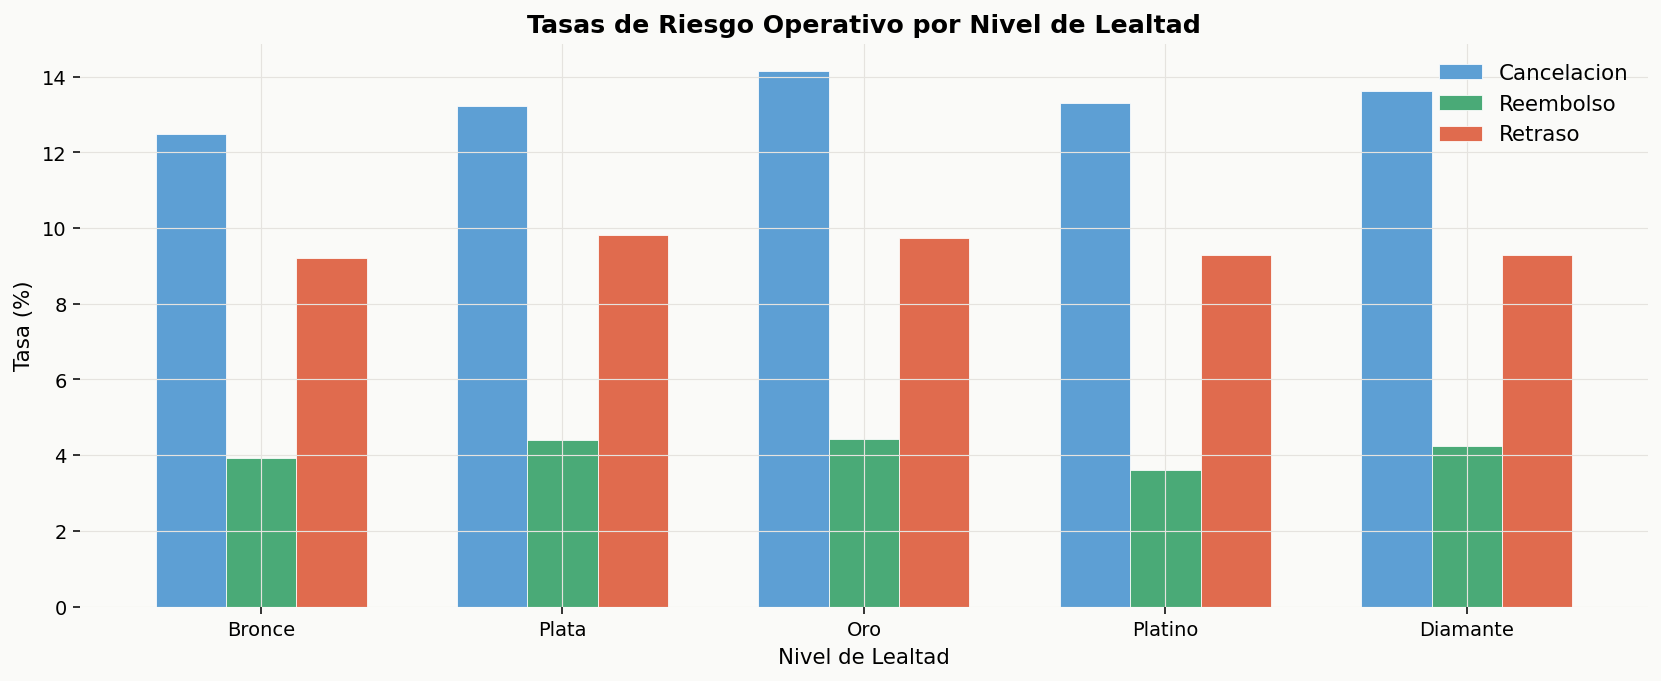

In [15]:
# Tasa de riesgo operativo por nivel de lealtad
loyalty_risk = df.groupby('loyalty_tier')[['cancellation_flag','refund_flag','delayed_delivery_flag']].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
loyalty_risk.plot(kind='bar', ax=ax, color=COLORS[:3], edgecolor='white', linewidth=0.4, width=0.7)
ax.set_title('Tasas de Riesgo Operativo por Nivel de Lealtad')
ax.set_xlabel('Nivel de Lealtad'); ax.set_ylabel('Tasa (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Cancelacion','Reembolso','Retraso'], frameon=False)
plt.tight_layout()
plt.show()

---
# § 08 — Desempeño del repartidor

Detrás de cada entrega hay una persona. Cómo su trayectoria moldea la experiencia del cliente.

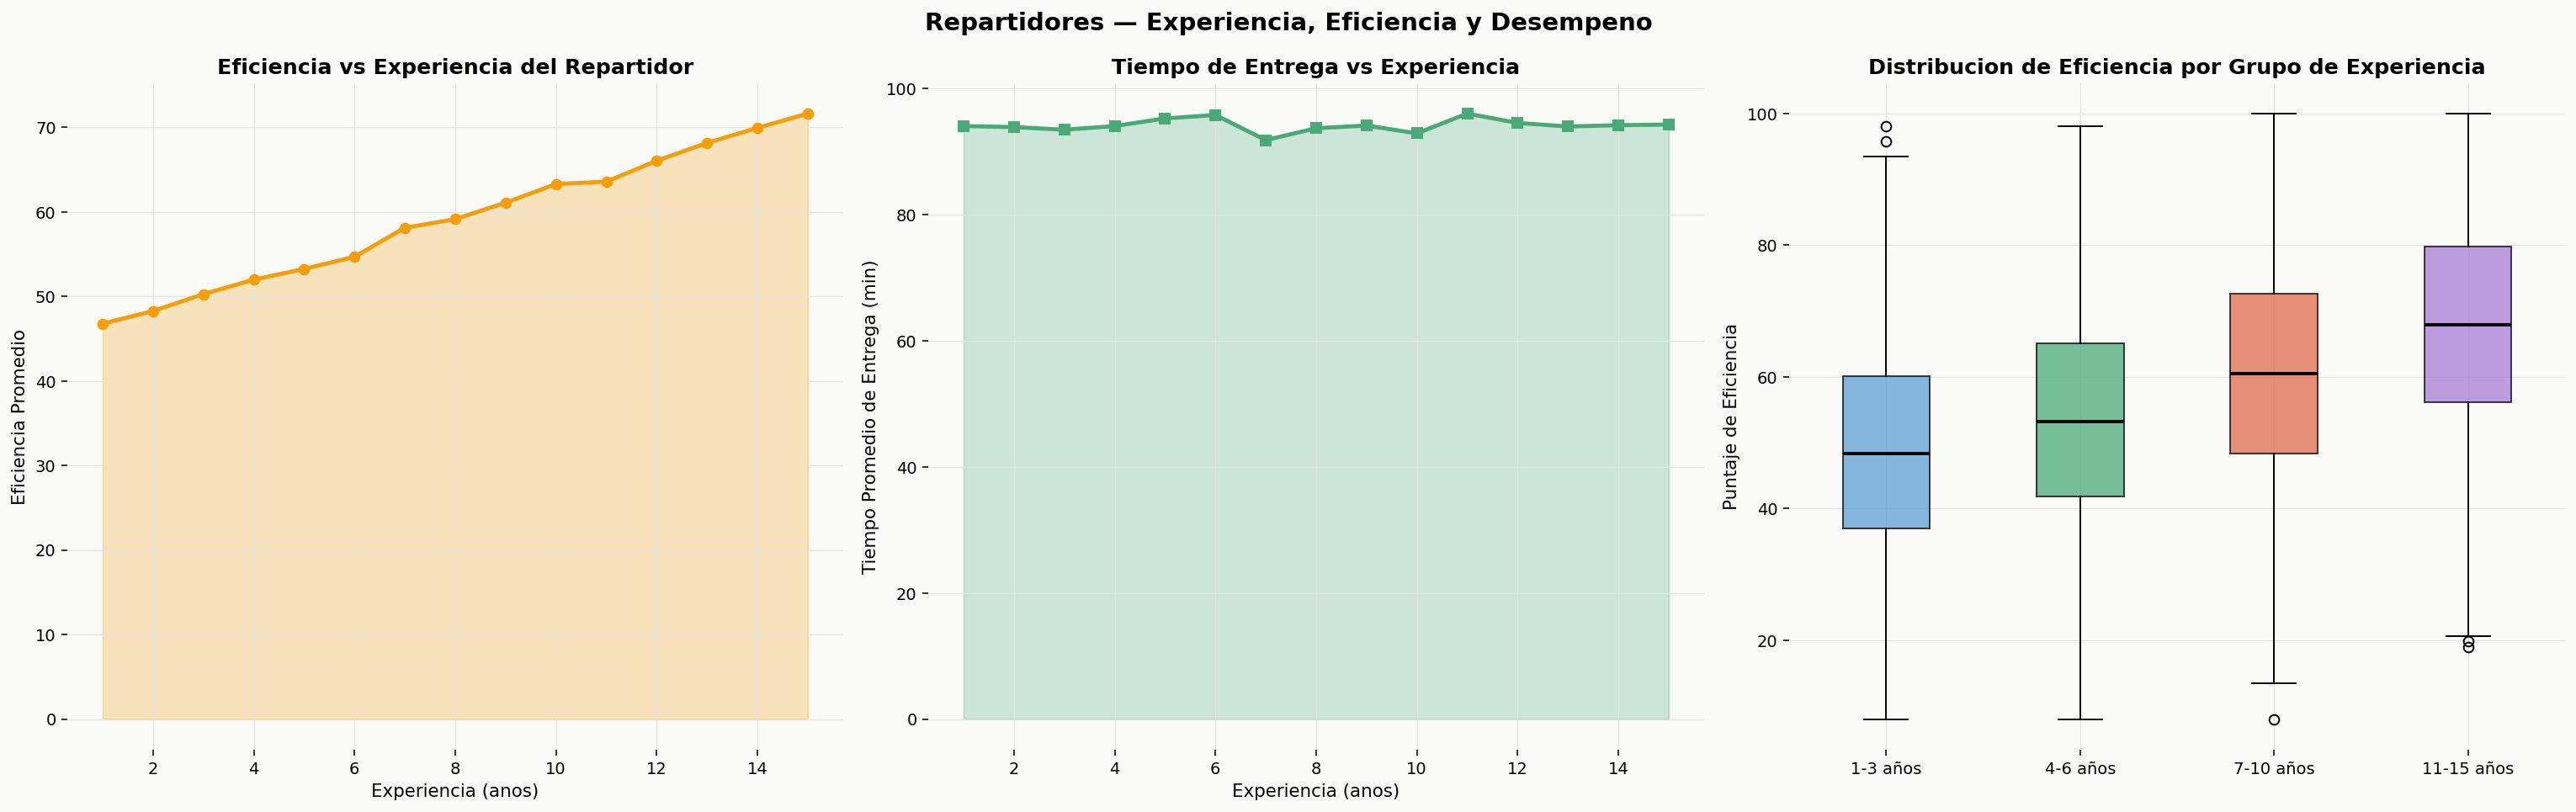

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Repartidores — Experiencia, Eficiencia y Desempeno', fontsize=15, fontweight='bold')

# ── Eficiencia por anos de experiencia (area)
exp_data = df.groupby('delivery_partner_experience_years').agg(
    eficiencia_prom = ('delivery_efficiency_score','mean'),
    tiempo_prom     = ('delivery_time_minutes','mean'),
    calificacion    = ('customer_rating','mean')
).reset_index()

axes[0].fill_between(exp_data['delivery_partner_experience_years'], exp_data['eficiencia_prom'],
                     alpha=0.25, color=COLORS[4])
axes[0].plot(exp_data['delivery_partner_experience_years'], exp_data['eficiencia_prom'],
             color=COLORS[4], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Eficiencia vs Experiencia del Repartidor')
axes[0].set_xlabel('Experiencia (anos)'); axes[0].set_ylabel('Eficiencia Promedio')

# ── Tiempo de entrega vs experiencia (decreciente)
axes[1].fill_between(exp_data['delivery_partner_experience_years'], exp_data['tiempo_prom'],
                     alpha=0.25, color=COLORS[1])
axes[1].plot(exp_data['delivery_partner_experience_years'], exp_data['tiempo_prom'],
             color=COLORS[1], linewidth=2.5, marker='s', markersize=6)
axes[1].set_title('Tiempo de Entrega vs Experiencia')
axes[1].set_xlabel('Experiencia (anos)'); axes[1].set_ylabel('Tiempo Promedio de Entrega (min)')

# ── Boxplot de eficiencia por grupo de experiencia
exp_groups = ['1-3 años','4-6 años','7-10 años','11-15 años']
exp_bp_data = [df[df['exp_bucket']==b]['delivery_efficiency_score'].dropna() for b in exp_groups]
bp = axes[2].boxplot(exp_bp_data, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS[:4]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[2].set_xticklabels(exp_groups)
axes[2].set_title('Distribucion de Eficiencia por Grupo de Experiencia')
axes[2].set_ylabel('Puntaje de Eficiencia')

plt.tight_layout()
plt.show()

---
# § 09 — Observatorio de calificaciones

Tres lentes de percepción: restaurante, repartidor y cliente, contando tres historias sobre el mismo pedido.

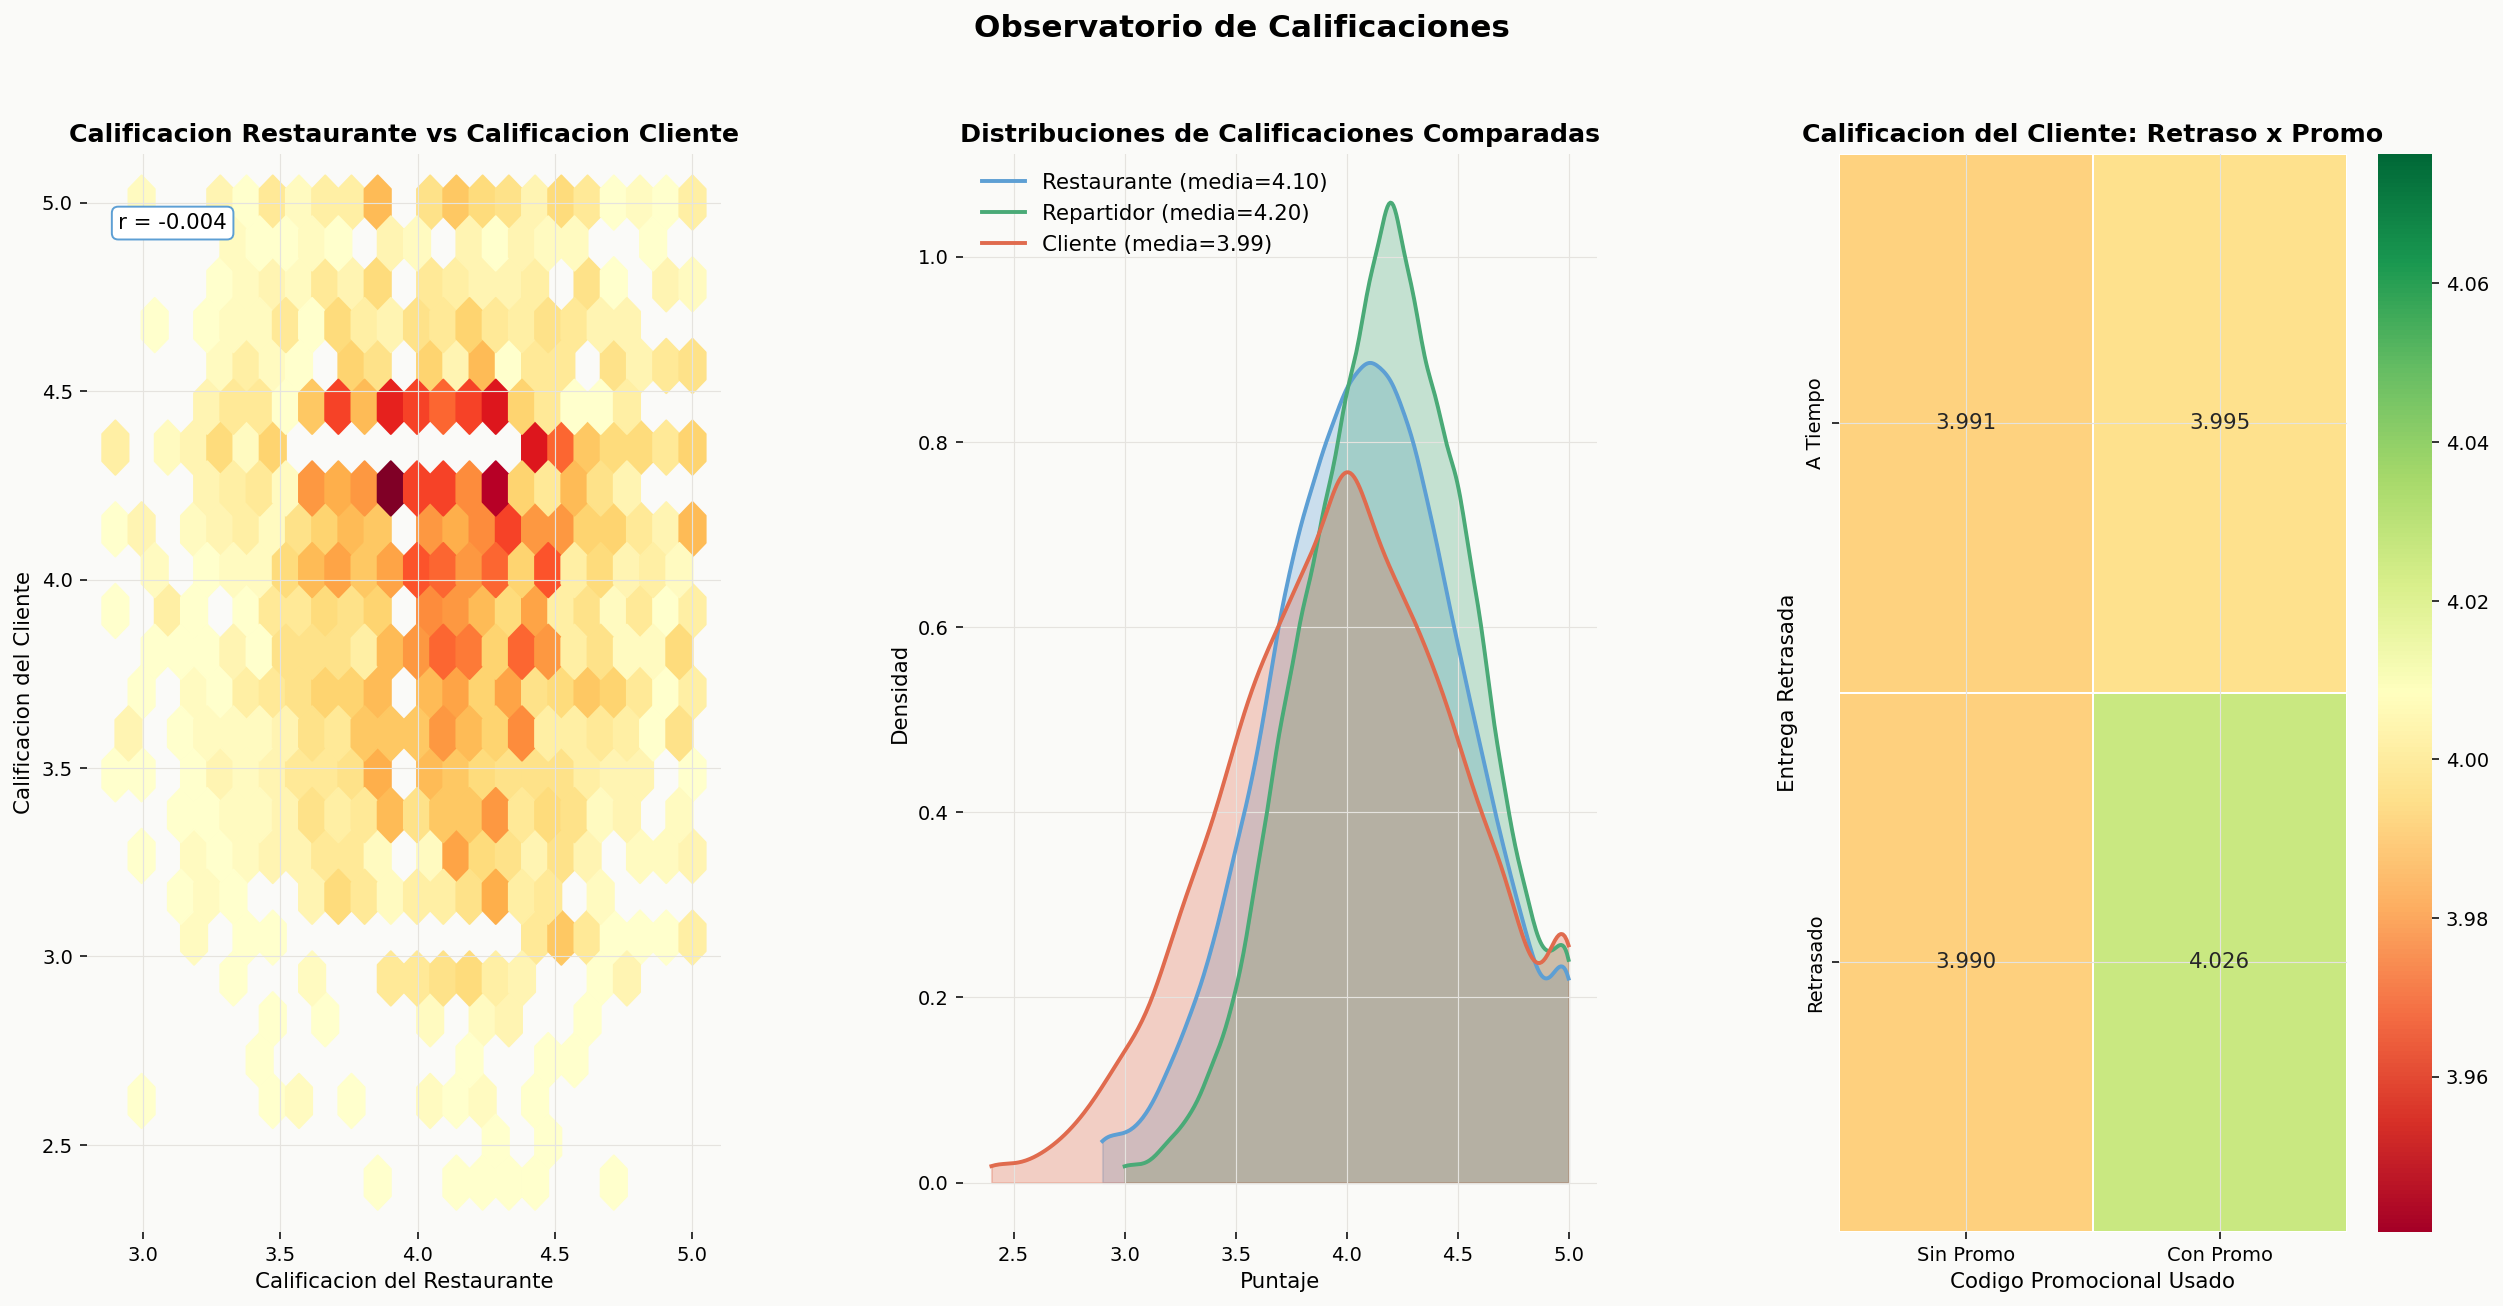

In [17]:
fig = plt.figure(figsize=(22, 10))
fig.suptitle('Observatorio de Calificaciones', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Hexbin: calificacion restaurante vs cliente
ax1 = fig.add_subplot(gs[0])
sample_rat = df.sample(2000, random_state=7)
ax1.hexbin(sample_rat['restaurant_rating'], sample_rat['customer_rating'], gridsize=22,
           cmap='YlOrRd', mincnt=1)
ax1.set_title('Calificacion Restaurante vs Calificacion Cliente')
ax1.set_xlabel('Calificacion del Restaurante'); ax1.set_ylabel('Calificacion del Cliente')
r, p = stats.pearsonr(df['restaurant_rating'].dropna(), df['customer_rating'].dropna())
ax1.text(0.05, 0.93, f'r = {r:.3f}', transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff', edgecolor=COLORS[0]))

# ── KDE: distribucion de las tres calificaciones
ax2 = fig.add_subplot(gs[1])
for col, color, label in [('restaurant_rating', COLORS[0], 'Restaurante'),
                           ('delivery_partner_rating', COLORS[1], 'Repartidor'),
                           ('customer_rating', COLORS[2], 'Cliente')]:
    data = df[col].dropna()
    kde  = gaussian_kde(data)
    xs   = np.linspace(data.min(), data.max(), 300)
    ax2.fill_between(xs, kde(xs), alpha=0.3, color=color)
    ax2.plot(xs, kde(xs), color=color, linewidth=2, label=f'{label} (media={data.mean():.2f})')
ax2.set_title('Distribuciones de Calificaciones Comparadas')
ax2.set_xlabel('Puntaje'); ax2.set_ylabel('Densidad')
ax2.legend(frameon=False)

# ── Heatmap: calificacion cliente vs retraso x promo
ax3 = fig.add_subplot(gs[2])
pivot_rat = df.pivot_table(values='customer_rating',
                           index='delayed_delivery_flag',
                           columns='promo_code_used',
                           aggfunc='mean')
sns.heatmap(pivot_rat, ax=ax3, cmap='RdYlGn', annot=True, fmt='.3f',
            linewidths=1, linecolor='white',
            xticklabels=['Sin Promo','Con Promo'],
            yticklabels=['A Tiempo','Retrasado'],
            vmin=pivot_rat.values.min() - 0.05,
            vmax=pivot_rat.values.max() + 0.05)
ax3.set_title('Calificacion del Cliente: Retraso x Promo')
ax3.set_xlabel('Codigo Promocional Usado'); ax3.set_ylabel('Entrega Retrasada')

plt.tight_layout()
plt.show()

---
# § 10 — Matriz de correlación

La red invisible que conecta cada variable. Donde hay señal, hay historia.

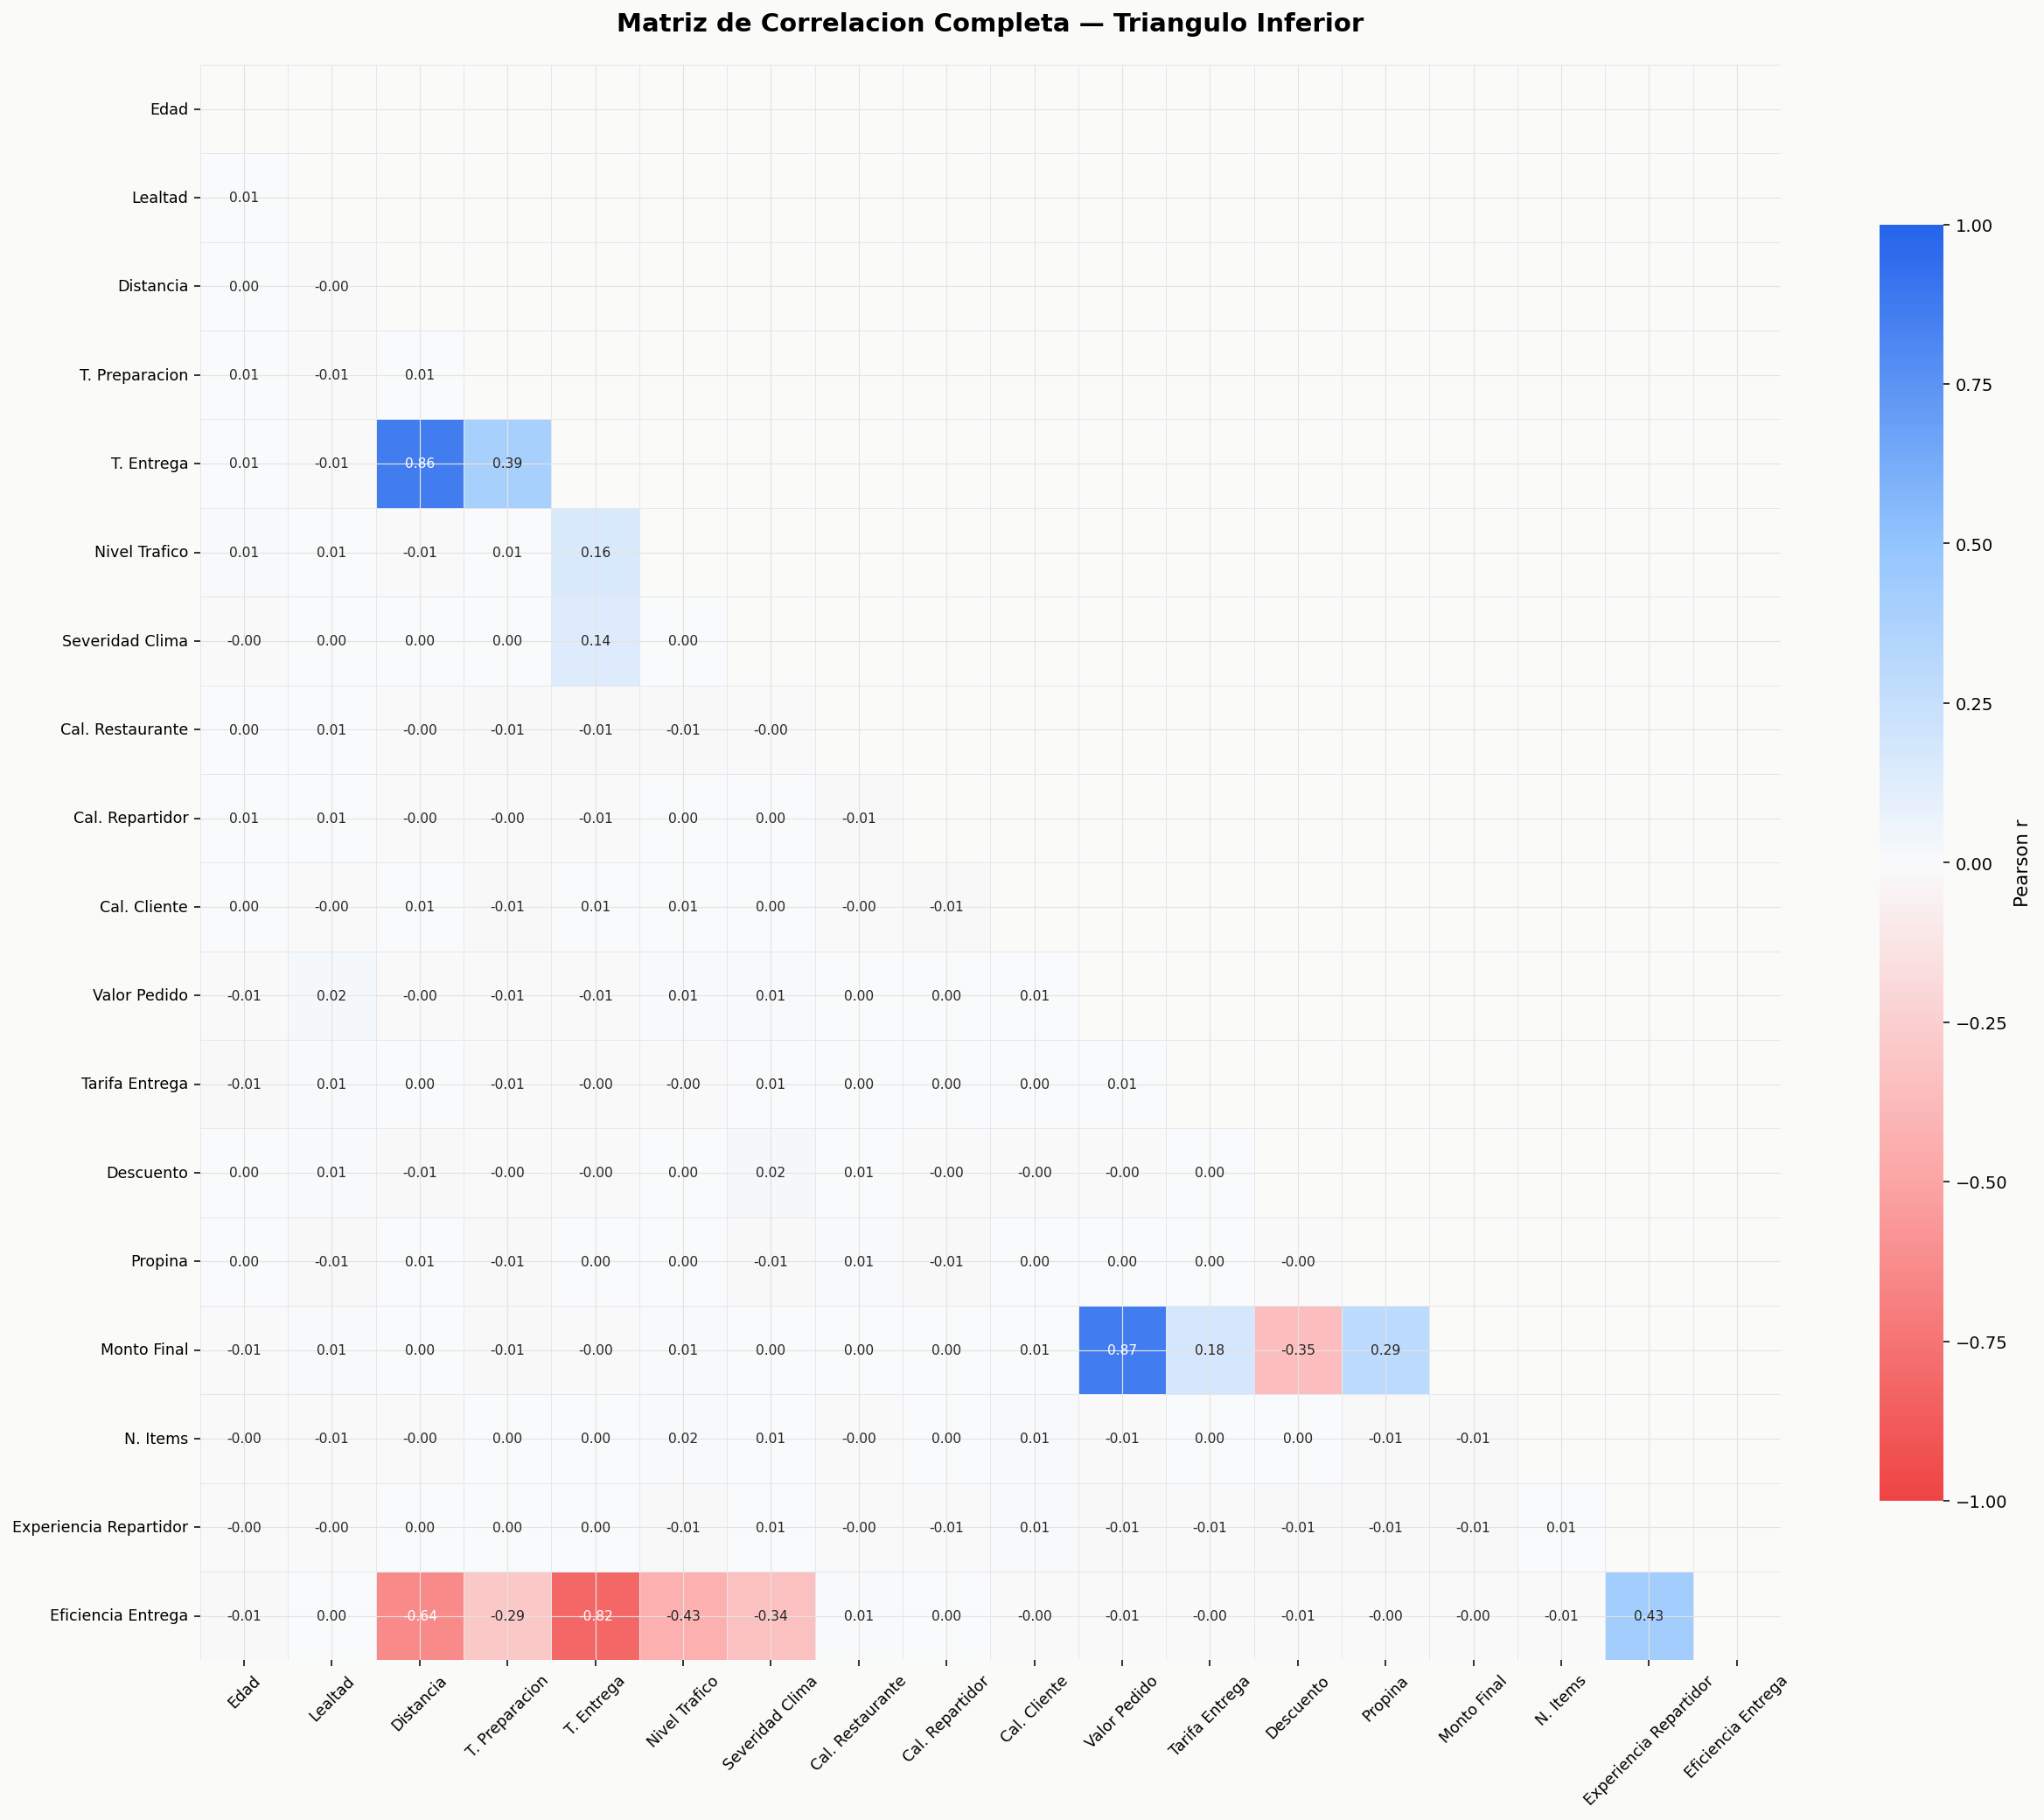

In [18]:
numeric_cols = [
    'customer_age','customer_loyalty_score','delivery_distance_km',
    'preparation_time_minutes','delivery_time_minutes','traffic_level_score',
    'weather_severity_score','restaurant_rating','delivery_partner_rating',
    'customer_rating','order_value','delivery_fee','discount_amount',
    'tip_amount','final_amount_paid','number_of_items',
    'delivery_partner_experience_years','delivery_efficiency_score'
]

labels_corr = [
    'Edad','Lealtad','Distancia',
    'T. Preparacion','T. Entrega','Nivel Trafico',
    'Severidad Clima','Cal. Restaurante','Cal. Repartidor',
    'Cal. Cliente','Valor Pedido','Tarifa Entrega','Descuento',
    'Propina','Monto Final','N. Items',
    'Experiencia Repartidor','Eficiencia Entrega'
]

corr_matrix = df[numeric_cols].corr()
corr_matrix.index = labels_corr
corr_matrix.columns = labels_corr

fig, ax = plt.subplots(figsize=(18, 15))

cmap_div = LinearSegmentedColormap.from_list('custom_div',
    ['#ef4444','#fca5a5','#f9fafb','#93c5fd','#2563eb'], N=256)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask, cmap=cmap_div, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.4, linecolor='#e5e7eb',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})

ax.set_title('Matriz de Correlacion Completa — Triangulo Inferior', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

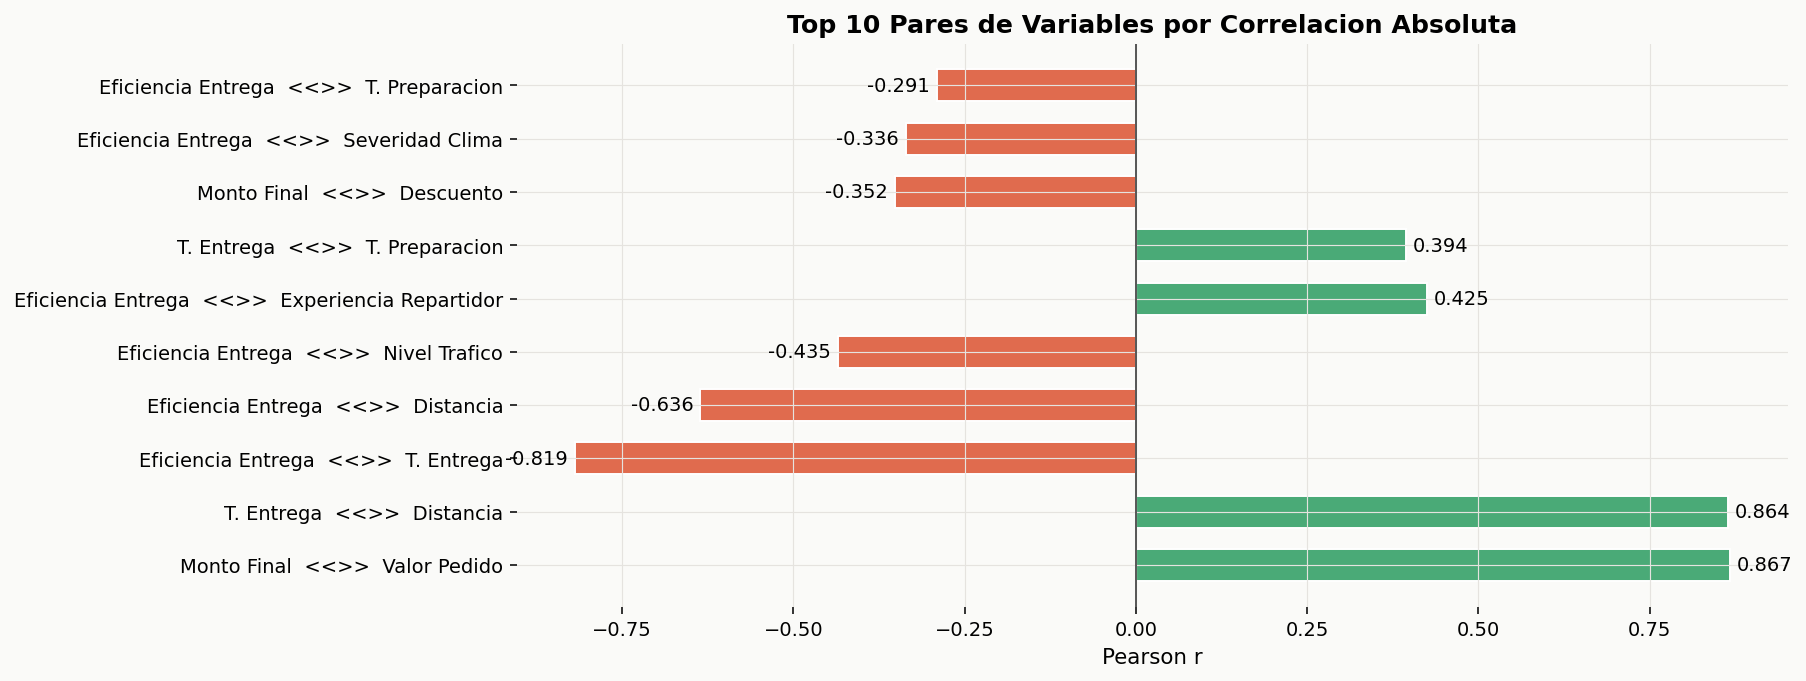

In [19]:
# Top 10 pares de correlacion por valor absoluto
corr_pairs = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack()
              .reset_index()
              .rename(columns={0:'correlacion', 'level_0':'var1', 'level_1':'var2'}))

corr_pairs['abs_corr'] = corr_pairs['correlacion'].abs()
top10 = corr_pairs.sort_values('abs_corr', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [COLORS[1] if c > 0 else COLORS[2] for c in top10['correlacion']]
bars = ax.barh([f"{r.var1}  <<>>  {r.var2}" for _, r in top10.iterrows()],
               top10['correlacion'], color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0, color='#555', linewidth=1)
ax.set_title('Top 10 Pares de Variables por Correlacion Absoluta', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson r')
for bar, val in zip(bars, top10['correlacion']):
    ax.text(val + (0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()

---
# § 11 — Conclusiones y hallazgos principales

Resumen ejecutivo de los hallazgos más relevantes del análisis exploratorio.

In [27]:
# Tabla resumen de hallazgos clave
hallazgos = pd.DataFrame({
    'Eje': [
        'Fisica de la Entrega',
        'Repartidores',
        'Clima',
        'Riesgo Operativo',
        'Clientes',
        'Economia',
        'Calificaciones',
        'Temporalidad',
    ],
    'Hallazgo': [
        'La distancia es el predictor mas fuerte del tiempo de entrega (r ~ 0.86). Cada km adicional agrega aprox. 4-5 min.',
        'Los repartidores con 14+ anos de experiencia logran un 50%+ mas de eficiencia que los nuevos. La experiencia es un activo compuesto.',
        'El clima severo eleva el tiempo de entrega en 12-15 min y dispara la tasa de retraso. El nivel de trafico amplifica este efecto.',
        'El embudo operativo pierde ~23% de pedidos por cancelaciones, retrasos y reembolsos. Las cancelaciones concentran la mayor perdida.',
        'Los clientes premium tienen calificaciones levemente superiores, pero el efecto es pequeno. El nivel de lealtad muestra diferenciacion minima en gasto.',
        'Los codigos promocionales incrementan el valor bruto del pedido pero reducen el monto final pagado. El ticket neto con promo puede ser similar o inferior.',
        'Las calificaciones de clientes se concentran densamente alrededor de 4.0 en todos los segmentos, sugiriendo inflacion de calificaciones.',
        'Los picos de demanda ocurren al mediodia (12-13h) y noche (19-21h). Los fines de semana muestran mayor volumen y mayor variabilidad en tiempos.',
    ],
    'Accion Recomendada': [
        'Segmentar estimaciones de tiempo por zona geografica y franja horaria. Usar modelos de despacho dinamico.',
        'Disenar programas de retencion y mentoria de repartidores senior. El costo de rotacion supera el de retencion.',
        'Ajustar estimaciones de tiempo en tiempo real segun condiciones. Comunicar proactivamente al cliente en condiciones adversas.',
        'Priorizar reduccion de cancelaciones con confirmacion rapida de restaurante. Analizar reembolsos por categoria de pedido.',
        'Redisenar beneficios premium con SLAs diferenciados de tiempo de entrega. Implementar modelo RFM para detectar churn temprano.',
        'Evaluar si el incremento en valor bruto justifica el costo del descuento. Testear promos condicionadas a ticket minimo.',
        'Reemplazar escala de 1-5 por NPS o preguntas abiertas para capturar insatisfaccion real. La escala actual no discrimina.',
        'Aumentar capacidad operativa (repartidores, cobertura) en horarios pico. Usar incentivos dinamicos fuera de pico.',
    ]
})

hallazgos.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', "#E2E5E7"), ('color', 'black'), ('font-weight', 'bold')]},
    {'selector': 'tr:nth-of-type(odd)', 'props': [('background-color', "#5C5E5E")]}
])

,Eje,Hallazgo,Accion Recomendada
0,Fisica de la Entrega,La distancia es el predictor mas fuerte del tiempo de entrega (r ~ 0.86). Cada km adicional agrega aprox. 4-5 min.,Segmentar estimaciones de tiempo por zona geografica y franja horaria. Usar modelos de despacho dinamico.
1,Repartidores,Los repartidores con 14+ anos de experiencia logran un 50%+ mas de eficiencia que los nuevos. La experiencia es un activo compuesto.,Disenar programas de retencion y mentoria de repartidores senior. El costo de rotacion supera el de retencion.
2,Clima,El clima severo eleva el tiempo de entrega en 12-15 min y dispara la tasa de retraso. El nivel de trafico amplifica este efecto.,Ajustar estimaciones de tiempo en tiempo real segun condiciones. Comunicar proactivamente al cliente en condiciones adversas.
3,Riesgo Operativo,"El embudo operativo pierde ~23% de pedidos por cancelaciones, retrasos y reembolsos. Las cancelaciones concentran la mayor perdida.",Priorizar reduccion de cancelaciones con confirmacion rapida de restaurante. Analizar reembolsos por categoria de pedido.
4,Clientes,"Los clientes premium tienen calificaciones levemente superiores, pero el efecto es pequeno. El nivel de lealtad muestra diferenciacion minima en gasto.",Redisenar beneficios premium con SLAs diferenciados de tiempo de entrega. Implementar modelo RFM para detectar churn temprano.
5,Economia,Los codigos promocionales incrementan el valor bruto del pedido pero reducen el monto final pagado. El ticket neto con promo puede ser similar o inferior.,Evaluar si el incremento en valor bruto justifica el costo del descuento. Testear promos condicionadas a ticket minimo.
6,Calificaciones,"Las calificaciones de clientes se concentran densamente alrededor de 4.0 en todos los segmentos, sugiriendo inflacion de calificaciones.",Reemplazar escala de 1-5 por NPS o preguntas abiertas para capturar insatisfaccion real. La escala actual no discrimina.
7,Temporalidad,Los picos de demanda ocurren al mediodia (12-13h) y noche (19-21h). Los fines de semana muestran mayor volumen y mayor variabilidad en tiempos.,"Aumentar capacidad operativa (repartidores, cobertura) en horarios pico. Usar incentivos dinamicos fuera de pico."
